# Medical Image Analysis for Skin Lesion Triage

**AUTHOR**  
Rodrigo Kang

## Overview

This notebook accompanies the project **Medical Image Analysis for Skin Lesion Triage** and provides the computational implementation for a seven-class dermoscopic image-classification study using the HAM10000 / ISIC 2018 Task 3 training data.

The work is framed as experimental decision support for prioritising lesions for further clinical review. It does not represent autonomous diagnosis, a clinically validated system, or a replacement for specialist assessment. The notebook will develop the analysis in stages, beginning with reproducible project configuration and later covering data integrity, leakage-aware splitting, PyTorch modelling, evaluation, and error analysis.

## Imports and Configuration

This section defines the minimal libraries, central configuration, relative paths, output folders, reproducibility controls, device selection, and lightweight validation helpers required at the start of the workflow.

The notebook is expected to run from the local `python/` directory. Source files are referenced through the sibling `../data/` directory, while generated artefacts are stored under `output/`. Deterministic PyTorch settings are enabled where practical, although exact bitwise reproducibility can still vary across hardware, drivers, and library versions.

In [1]:
# Standard-library imports
import os
import platform
import random
from pathlib import Path

# Configure the CUDA workspace before importing PyTorch.
os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")

# Third-party imports required for initial configuration
import numpy as np
import torch
import torchvision

# Central configuration
random_seed = 42
project_dir = Path.cwd()

data_dir = Path("../data")
image_archive_path = Path("../data/ISIC-images.zip")
metadata_path = Path(
    "../data/challenge-2018-task-3-training_metadata_2026-06-20.csv"
)

output_dir = Path("output")
figures_dir = output_dir / "figures"
tables_dir = output_dir / "tables"
models_dir = output_dir / "models"
metadata_output_dir = output_dir / "metadata"

output_directories = [
    output_dir,
    figures_dir,
    tables_dir,
    models_dir,
    metadata_output_dir,
]

required_source_paths = {
    "image archive": image_archive_path,
    "training metadata": metadata_path,
}

def create_directories(directories: list[Path]) -> None:
    """
    Create the required local directories when they do not already exist.

    Input:
    ------
    directories : list[Path]
        Directory paths to create.

    Outputs:
    --------
    None
        The function creates directories on the local file system.

    Author:
    -------
    Rodrigo Kang
    """
    for directory in directories:
        directory.mkdir(parents=True, exist_ok=True)

def set_reproducibility(seed: int) -> None:
    """
    Apply fixed random seeds and practical deterministic PyTorch settings.

    Input:
    ------
    seed : int
        Random seed used by Python, NumPy, and PyTorch.

    Outputs:
    --------
    None
        The function updates random-number and backend settings in place.

    Author:
    -------
    Rodrigo Kang
    """
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True, warn_only=True)

def validate_paths(paths: dict[str, Path]) -> None:
    """
    Confirm that required source paths exist without reading their contents.

    Input:
    ------
    paths : dict[str, Path]
        Descriptive names mapped to required file paths.

    Outputs:
    --------
    None
        The function raises FileNotFoundError when a required path is absent.

    Author:
    -------
    Rodrigo Kang
    """
    missing_paths = [
        f"{name}: {path}"
        for name, path in paths.items()
        if not path.is_file()
    ]

    if missing_paths:
        missing_text = "\n".join(f"- {item}" for item in missing_paths)
        raise FileNotFoundError(
            "Required source files were not found. Run the notebook from the "
            f"python/ directory and confirm these paths:\n{missing_text}"
        )

create_directories(output_directories)
set_reproducibility(random_seed)
validate_paths(required_source_paths)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Project directory: {project_dir}")
print(f"Python: {platform.python_version()}")
print(f"NumPy: {np.__version__}")
print(f"PyTorch: {torch.__version__}")
print(f"torchvision: {torchvision.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Selected device: {device}")

if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")

print("Required source paths: available")
print("Output directories: ready")

Project directory: C:\Users\rodrigokang\Desktop\profile\portfolio\notebooks-and-scripts\1-applied-data-science\8-skin-lesion-triage\python
Python: 3.12.13
NumPy: 2.5.1
PyTorch: 2.13.0+cpu
torchvision: 0.28.0+cpu
CUDA available: False
Selected device: cpu
Required source paths: available
Output directories: ready


## Data Loading

This section loads the supplied training metadata and inventories the image archive without extracting it. The audit establishes whether the tabular records, image identifiers and lesion identifiers are internally consistent before any modelling decisions are made.

The collection page reports 10,015 training images and 7,470 specified lesions. The HAM10000 paper describes a multi-source dermoscopic collection assembled from routine practice and research archives, with ground truth based on histopathology where available and otherwise on follow-up, expert consensus or confocal microscopy. These confirmation routes are not equivalent, so their distribution is retained as part of the audit rather than treated as incidental metadata.

The seven target categories follow the ISIC 2018 Task 3 formulation: `akiec`, `bcc`, `bkl`, `df`, `mel`, `nv` and `vasc`. The challenge paper used balanced accuracy because ordinary accuracy is strongly influenced by the uneven class prevalence. It also showed that performance on internally sourced images did not necessarily transfer to an external partition, which limits how far results from this notebook can be generalised.

**Primary references**

- Tschandl, Rosendahl and Kittler (2018), *The HAM10000 dataset, a large collection of multi-source dermatoscopic images of common pigmented skin lesions*.
- Codella et al. (2019), *Skin Lesion Analysis Toward Melanoma Detection 2018: A Challenge Hosted by the International Skin Imaging Collaboration*.
- ISIC Archive, *Challenge 2018: Task 3: Training*, collection 66.

In [2]:
# Imports required for data loading and archive inspection
import io
import zipfile

import pandas as pd
from PIL import Image

class_names = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]

def load_training_metadata(file_path: Path) -> pd.DataFrame:
    """
    Load the supplied ISIC training metadata table.

    Input:
    ------
    file_path : Path
        Relative path to the metadata CSV file.

    Outputs:
    --------
    metadata : pd.DataFrame
        Metadata table with one row per image record.

    Author:
    -------
    Rodrigo Kang
    """
    metadata = pd.read_csv(file_path)

    if metadata.empty:
        raise ValueError("The metadata file contains no records.")

    return metadata

def list_archive_images(archive_path: Path) -> pd.DataFrame:
    """
    Inventory JPEG images stored in the supplied ZIP archive.

    Input:
    ------
    archive_path : Path
        Relative path to the image archive.

    Outputs:
    --------
    archive_inventory : pd.DataFrame
        Image member names, identifiers and compressed file sizes.

    Author:
    -------
    Rodrigo Kang
    """
    with zipfile.ZipFile(archive_path) as archive:
        image_records = [
            {
                "archive_member": member.filename,
                "isic_id": Path(member.filename).stem,
                "compressed_bytes": member.compress_size,
                "uncompressed_bytes": member.file_size,
            }
            for member in archive.infolist()
            if not member.is_dir()
            and Path(member.filename).suffix.lower() in {".jpg", ".jpeg"}
        ]

    archive_inventory = pd.DataFrame(image_records)

    if archive_inventory.empty:
        raise ValueError("No JPEG images were found in the image archive.")

    return archive_inventory

def assign_target_class(metadata: pd.DataFrame) -> pd.Series:
    """
    Map archive diagnosis fields to the seven ISIC 2018 target classes.

    Input:
    ------
    metadata : pd.DataFrame
        Training metadata containing diagnosis fields.

    Outputs:
    --------
    target : pd.Series
        Seven-class target label aligned to the metadata index.

    Author:
    -------
    Rodrigo Kang
    """
    diagnosis_3_mapping = {
        "Nevus": "nv",
        "Melanoma, NOS": "mel",
        "Pigmented benign keratosis": "bkl",
        "Basal cell carcinoma": "bcc",
        "Dermatofibroma": "df",
        "Solar or actinic keratosis": "akiec",
        "Squamous cell carcinoma, NOS": "akiec",
    }

    target = metadata["diagnosis_3"].map(diagnosis_3_mapping)
    vascular_mask = metadata["diagnosis_2"].eq(
        "Benign soft tissue proliferations - Vascular"
    )
    target = target.mask(vascular_mask, "vasc")

    unresolved_rows = metadata.loc[target.isna(), ["diagnosis_2", "diagnosis_3"]]
    if not unresolved_rows.empty:
        unresolved_values = unresolved_rows.drop_duplicates().to_dict("records")
        raise ValueError(
            "Some diagnosis combinations could not be mapped to the seven "
            f"target classes: {unresolved_values}"
        )

    return target

metadata = load_training_metadata(metadata_path)
archive_inventory = list_archive_images(image_archive_path)
metadata = metadata.copy()
metadata["target"] = assign_target_class(metadata)

print(f"Metadata shape: {metadata.shape[0]:,} rows x {metadata.shape[1]:,} columns")
print(f"JPEG images in archive: {len(archive_inventory):,}")
print(f"Unique image identifiers: {metadata['isic_id'].nunique():,}")
print(f"Unique lesion identifiers: {metadata['lesion_id'].nunique():,}")
print(f"Target classes: {sorted(metadata['target'].unique())}")

display(metadata.head())

Metadata shape: 10,015 rows x 18 columns
JPEG images in archive: 10,015
Unique image identifiers: 10,015
Unique lesion identifiers: 7,470
Target classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


,isic_id,attribution,copyright_license,age_approx,anatom_site_1,anatom_site_2,anatom_site_3,anatom_site_special,concomitant_biopsy,diagnosis_1,diagnosis_2,diagnosis_3,diagnosis_confirm_type,image_type,lesion_id,melanocytic,sex,target
0,ISIC_0024306,"ViDIR Group, Department of Dermatology, Medica...",CC-BY-NC,45.0,Trunk,NaN,NaN,NaN,False,Benign,Benign melanocytic proliferations,Nevus,serial imaging showing no change,dermoscopic,IL_7252831,True,male,nv
1,ISIC_0024307,"ViDIR Group, Department of Dermatology, Medica...",CC-BY-NC,50.0,Lower extremity,NaN,NaN,NaN,False,Benign,Benign melanocytic proliferations,Nevus,serial imaging showing no change,dermoscopic,IL_6125741,True,male,nv
2,ISIC_0024308,"ViDIR Group, Department of Dermatology, Medica...",CC-BY-NC,55.0,Trunk,NaN,NaN,NaN,False,Benign,Benign melanocytic proliferations,Nevus,serial imaging showing no change,dermoscopic,IL_3692653,True,female,nv
3,ISIC_0024309,"ViDIR Group, Department of Dermatology, Medica...",CC-BY-NC,40.0,Trunk,NaN,NaN,NaN,False,Benign,Benign melanocytic proliferations,Nevus,serial imaging showing no change,dermoscopic,IL_0959663,True,male,nv
4,ISIC_0024310,"ViDIR Group, Department of Dermatology, Medica...",CC-BY-NC,60.0,Trunk,Anterior trunk,Anterior chest,NaN,True,Malignant,Malignant melanocytic proliferations (Melanoma),"Melanoma, NOS",histopathology,dermoscopic,IL_8194852,True,male,mel


## Data Preparation

This section reconciles the metadata with the image archive and checks the identifiers that will later govern leakage-aware splitting. It does not create train, validation or test assignments.

An image identifier should occur once in the metadata and once in the archive. A lesion identifier may occur more than once because HAM10000 includes multiple views or acquisitions of some lesions. Those repeated records are legitimate, but every image belonging to the same lesion must remain together when the fixed experimental split is created in a later part.

The audit also records missingness and the distribution of confirmation methods. Histopathology is the strongest available reference standard in this collection, while stable serial imaging, expert consensus and confocal microscopy were used for selected cases described by the dataset authors. These labels remain suitable for the benchmark task, but the mixture should be acknowledged when interpreting model errors.

In [3]:
required_metadata_columns = {
    "isic_id",
    "lesion_id",
    "diagnosis_1",
    "diagnosis_2",
    "diagnosis_3",
    "diagnosis_confirm_type",
    "age_approx",
    "sex",
    "anatom_site_1",
    "image_type",
    "target",
}
missing_columns = required_metadata_columns.difference(metadata.columns)

if missing_columns:
    raise ValueError(
        "Required metadata columns are missing: "
        f"{sorted(missing_columns)}"
    )

metadata_image_ids = set(metadata["isic_id"])
archive_image_ids = set(archive_inventory["isic_id"])

metadata_without_image = sorted(metadata_image_ids - archive_image_ids)
images_without_metadata = sorted(archive_image_ids - metadata_image_ids)

images_per_lesion = metadata.groupby("lesion_id").size().rename("image_count")
lesion_count_distribution = (
    images_per_lesion.value_counts()
    .sort_index()
    .rename_axis("images_per_lesion")
    .reset_index(name="lesion_count")
)

missingness_summary = (
    metadata.isna()
    .sum()
    .rename("missing_count")
    .to_frame()
    .assign(missing_percent=lambda table: 100 * table["missing_count"] / len(metadata))
    .query("missing_count > 0")
    .sort_values("missing_percent", ascending=False)
    .reset_index(names="column")
)

class_distribution = (
    metadata["target"]
    .value_counts()
    .reindex(class_names)
    .rename("image_count")
    .to_frame()
    .assign(image_percent=lambda table: 100 * table["image_count"] / len(metadata))
    .reset_index(names="target")
)

confirmation_distribution = (
    metadata["diagnosis_confirm_type"]
    .value_counts(dropna=False)
    .rename("image_count")
    .to_frame()
    .assign(image_percent=lambda table: 100 * table["image_count"] / len(metadata))
    .reset_index(names="diagnosis_confirm_type")
)

integrity_summary = pd.DataFrame(
    {
        "check": [
            "metadata rows",
            "archive JPEG images",
            "duplicate metadata rows",
            "duplicate metadata image identifiers",
            "duplicate archive image identifiers",
            "metadata records without image",
            "archive images without metadata",
            "unique lesions",
            "lesions with multiple images",
        ],
        "value": [
            len(metadata),
            len(archive_inventory),
            int(metadata.duplicated().sum()),
            int(metadata["isic_id"].duplicated().sum()),
            int(archive_inventory["isic_id"].duplicated().sum()),
            len(metadata_without_image),
            len(images_without_metadata),
            metadata["lesion_id"].nunique(),
            int((images_per_lesion > 1).sum()),
        ],
    }
)

if set(metadata["target"].unique()) != set(class_names):
    raise ValueError("The derived target does not contain the expected seven classes.")

if metadata_without_image or images_without_metadata:
    raise ValueError(
        "Metadata and archive identifiers do not reconcile. "
        f"Metadata without image: {len(metadata_without_image)}; "
        f"images without metadata: {len(images_without_metadata)}."
    )

integrity_summary.to_csv(
    tables_dir / "data-integrity-summary.csv", index=False
)
missingness_summary.to_csv(
    tables_dir / "metadata-missingness.csv", index=False
)
class_distribution.to_csv(
    tables_dir / "class-distribution.csv", index=False
)
confirmation_distribution.to_csv(
    tables_dir / "confirmation-methods.csv", index=False
)
lesion_count_distribution.to_csv(
    tables_dir / "images-per-lesion.csv", index=False
)

print("Identifier reconciliation: passed")
print(f"Lesions with multiple images: {(images_per_lesion > 1).sum():,}")
print(f"Maximum images for one lesion: {images_per_lesion.max():,}")

display(integrity_summary)
display(class_distribution)
display(confirmation_distribution)
display(missingness_summary)

Identifier reconciliation: passed
Lesions with multiple images: 1,956
Maximum images for one lesion: 6


,check,value
0,metadata rows,10015
1,archive JPEG images,10015
2,duplicate metadata rows,0
3,duplicate metadata image identifiers,0
4,duplicate archive image identifiers,0
5,metadata records without image,0
6,archive images without metadata,0
7,unique lesions,7470
8,lesions with multiple images,1956


,target,image_count,image_percent
0,akiec,327,3.265102
1,bcc,514,5.132302
2,bkl,1099,10.973540
3,df,115,1.148278
4,mel,1113,11.113330
5,nv,6705,66.949576
6,vasc,142,1.417873


,diagnosis_confirm_type,image_count,image_percent
0,histopathology,5340,53.320020
1,serial imaging showing no change,3704,36.984523
2,single image expert consensus,902,9.006490
3,confocal microscopy with consensus dermoscopy,69,0.688967


,column,missing_count,missing_percent
0,anatom_site_special,9551,95.366950
1,anatom_site_3,7657,76.455317
2,anatom_site_2,4840,48.327509
3,anatom_site_1,241,2.406390
4,diagnosis_3,142,1.417873
5,age_approx,94,0.938592
6,sex,47,0.469296


## Exploratory Analysis (Optional)

This section completes a bounded image-level audit directly inside the ZIP archive. Every JPEG is opened and verified without extracting the collection. The check records image dimensions, colour mode and format, and reports unreadable files.

The resulting summaries establish whether a single loading strategy is appropriate. They are not an analysis of lesion appearance, demographics or model inputs; those exploratory questions remain for the next part. Only a compact class-distribution plot is included here to make the imbalance visible before the evaluation protocol is defined.

Images verified: 10,015
Unreadable images: 0


,width,height,mode,format,image_count
0,600,450,RGB,JPEG,10015


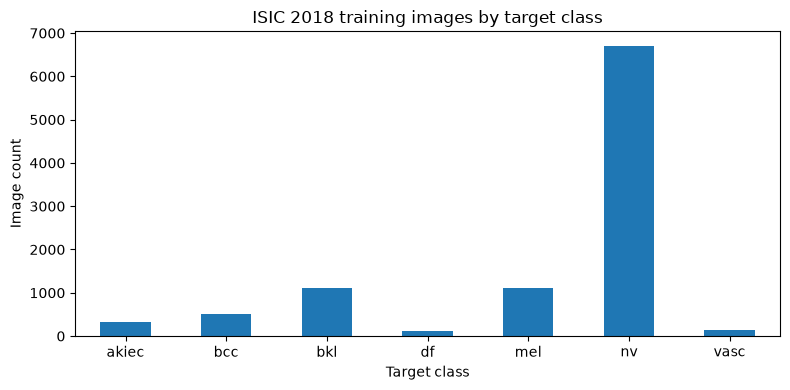

In [4]:
import matplotlib.pyplot as plt

def audit_archive_images(
    archive_path: Path,
    image_members: pd.Series,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Verify archived images and summarise their technical properties.

    Input:
    ------
    archive_path : Path
        Relative path to the ZIP archive containing the images.
    image_members : pd.Series
        Archive member names for the JPEG images to inspect.

    Outputs:
    --------
    image_properties : pd.DataFrame
        Technical properties recorded for readable images.
    image_errors : pd.DataFrame
        Member names and error messages for unreadable images.

    Author:
    -------
    Rodrigo Kang
    """
    property_records = []
    error_records = []

    with zipfile.ZipFile(archive_path) as archive:
        for member_name in image_members:
            try:
                image_bytes = archive.read(member_name)

                with Image.open(io.BytesIO(image_bytes)) as image:
                    image.verify()

                with Image.open(io.BytesIO(image_bytes)) as image:
                    property_records.append(
                        {
                            "archive_member": member_name,
                            "width": image.width,
                            "height": image.height,
                            "mode": image.mode,
                            "format": image.format,
                        }
                    )
            except (OSError, ValueError, zipfile.BadZipFile) as error:
                error_records.append(
                    {
                        "archive_member": member_name,
                        "error": str(error),
                    }
                )

    image_properties = pd.DataFrame(property_records)
    image_errors = pd.DataFrame(
        error_records,
        columns=["archive_member", "error"],
    )

    return image_properties, image_errors


image_properties, image_errors = audit_archive_images(
    image_archive_path,
    archive_inventory["archive_member"],
)

image_property_summary = (
    image_properties.groupby(["width", "height", "mode", "format"])
    .size()
    .rename("image_count")
    .reset_index()
    .sort_values("image_count", ascending=False)
)

image_property_summary.to_csv(
    tables_dir / "image-property-summary.csv", index=False
)
image_errors.to_csv(
    tables_dir / "unreadable-images.csv", index=False
)

print(f"Images verified: {len(image_properties):,}")
print(f"Unreadable images: {len(image_errors):,}")
display(image_property_summary)

class_plot = class_distribution.set_index("target")["image_count"]
axis = class_plot.plot(kind="bar", figsize=(8, 4))
axis.set_title("ISIC 2018 training images by target class")
axis.set_xlabel("Target class")
axis.set_ylabel("Image count")
axis.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.savefig(
    figures_dir / "class-distribution.png",
    dpi=160,
    bbox_inches="tight",
)
plt.show()

## Methodology

This section defines a leakage-aware experimental protocol for the seven-class classification task. Images are split by `lesion_id`, rather than by image identifier, so that multiple photographs of the same lesion cannot appear in different subsets. The resulting train, validation and test partitions are approximately 71%, 14% and 14% of the available images.

The training pipeline uses moderate geometric and colour augmentation, while validation and test images receive deterministic resizing and normalisation. ImageNet statistics are used because the transfer-learning model introduced in the next section will begin from ImageNet-pretrained weights.

Class imbalance is handled through inverse-square-root class weights in the loss function. This is less aggressive than direct inverse-frequency weighting and reduces the risk that a small class dominates gradient updates. The split itself remains stratified at lesion level, and all partitions are audited before model development begins.

In [5]:
# Imports required for splitting, transformations and data loading
from collections.abc import Callable
from typing import Optional

from sklearn.model_selection import StratifiedGroupKFold
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

# Experimental configuration
image_size = 224
batch_size = 32
number_of_workers = 0  # Reliable default for Windows and ZIP-backed loading.
pin_memory = torch.cuda.is_available()

imagenet_mean = (0.485, 0.456, 0.406)
imagenet_std = (0.229, 0.224, 0.225)

class_to_index = {
    class_name: class_index
    for class_index, class_name in enumerate(class_names)
}
index_to_class = {
    class_index: class_name
    for class_name, class_index in class_to_index.items()
}

def validate_lesion_targets(metadata_table: pd.DataFrame) -> None:
    """
    Confirm that each lesion identifier maps to a single target class.

    Input:
    ------
    metadata_table : pd.DataFrame
        Image-level metadata containing lesion and target identifiers.

    Outputs:
    --------
    None
        The function raises ValueError when a lesion has conflicting labels.

    Author:
    -------
    Rodrigo Kang
    """
    targets_per_lesion = metadata_table.groupby("lesion_id")["target"].nunique()
    conflicting_lesions = targets_per_lesion[targets_per_lesion > 1]

    if not conflicting_lesions.empty:
        raise ValueError(
            "Some lesion identifiers map to more than one target class: "
            f"{conflicting_lesions.index.tolist()[:10]}"
        )

def create_group_stratified_splits(
    metadata_table: pd.DataFrame,
    seed: int,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Create lesion-disjoint train, validation and test partitions.

    Input:
    ------
    metadata_table : pd.DataFrame
        Image-level metadata with target labels and lesion identifiers.
    seed : int
        Random seed used by the stratified group splitters.

    Outputs:
    --------
    train_metadata : pd.DataFrame
        Training records.
    validation_metadata : pd.DataFrame
        Validation records.
    test_metadata : pd.DataFrame
        Held-out test records.

    Author:
    -------
    Rodrigo Kang
    """
    validate_lesion_targets(metadata_table)

    outer_splitter = StratifiedGroupKFold(
        n_splits=7,
        shuffle=True,
        random_state=seed,
    )
    development_indices, test_indices = next(
        outer_splitter.split(
            metadata_table,
            y=metadata_table["target"],
            groups=metadata_table["lesion_id"],
        )
    )

    development_metadata = metadata_table.iloc[development_indices].copy()
    test_metadata = metadata_table.iloc[test_indices].copy()

    inner_splitter = StratifiedGroupKFold(
        n_splits=6,
        shuffle=True,
        random_state=seed + 1,
    )
    train_indices, validation_indices = next(
        inner_splitter.split(
            development_metadata,
            y=development_metadata["target"],
            groups=development_metadata["lesion_id"],
        )
    )

    train_metadata = development_metadata.iloc[train_indices].copy()
    validation_metadata = development_metadata.iloc[validation_indices].copy()

    for split_table in (train_metadata, validation_metadata, test_metadata):
        split_table["target_index"] = (
            split_table["target"].map(class_to_index).astype("int64")
        )
        split_table.reset_index(drop=True, inplace=True)

    return train_metadata, validation_metadata, test_metadata

def audit_split_integrity(
    train_metadata: pd.DataFrame,
    validation_metadata: pd.DataFrame,
    test_metadata: pd.DataFrame,
) -> pd.DataFrame:
    """
    Verify lesion separation and summarise split composition.

    Input:
    ------
    train_metadata : pd.DataFrame
        Training records.
    validation_metadata : pd.DataFrame
        Validation records.
    test_metadata : pd.DataFrame
        Test records.

    Outputs:
    --------
    split_summary : pd.DataFrame
        Image, lesion and class counts for each split.

    Author:
    -------
    Rodrigo Kang
    """
    train_lesions = set(train_metadata["lesion_id"])
    validation_lesions = set(validation_metadata["lesion_id"])
    test_lesions = set(test_metadata["lesion_id"])

    overlap_counts = {
        "train_validation": len(train_lesions & validation_lesions),
        "train_test": len(train_lesions & test_lesions),
        "validation_test": len(validation_lesions & test_lesions),
    }

    if any(overlap_counts.values()):
        raise ValueError(
            "Lesion leakage was detected between data partitions: "
            f"{overlap_counts}"
        )

    split_tables = {
        "train": train_metadata,
        "validation": validation_metadata,
        "test": test_metadata,
    }
    summary_records = []

    for split_name, split_table in split_tables.items():
        class_counts = split_table["target"].value_counts()

        summary_record = {
            "split": split_name,
            "image_count": len(split_table),
            "image_percent": 100 * len(split_table) / len(metadata),
            "lesion_count": split_table["lesion_id"].nunique(),
        }
        summary_record.update(
            {
                f"{class_name}_count": int(class_counts.get(class_name, 0))
                for class_name in class_names
            }
        )
        summary_records.append(summary_record)

    return pd.DataFrame(summary_records)

class ZipImageDataset(Dataset):
    """
    Load dermoscopic images lazily from a ZIP archive.

    The dataset keeps one archive handle per process. The notebook uses
    ``num_workers=0`` by default, which is the most reliable Windows setting
    for a ZIP-backed dataset.
    """

    def __init__(
        self,
        metadata_table: pd.DataFrame,
        archive_path: Path,
        archive_lookup: dict[str, str],
        transform: Optional[Callable] = None,
    ) -> None:
        """
        Initialise the ZIP-backed image dataset.

        Input:
        ------
        metadata_table : pd.DataFrame
            Records containing image identifiers and integer targets.
        archive_path : Path
            Path to the ZIP archive.
        archive_lookup : dict[str, str]
            Mapping from image identifier to archive member name.
        transform : Optional[Callable]
            Image transformation pipeline.

        Outputs:
        --------
        None
            The dataset stores the supplied configuration.

        Author:
        -------
        Rodrigo Kang
        """
        self.metadata_table = metadata_table.reset_index(drop=True).copy()
        self.archive_path = Path(archive_path)
        self.archive_lookup = archive_lookup
        self.transform = transform
        self._archive = None

    def __len__(self) -> int:
        """Return the number of image records in the dataset."""
        return len(self.metadata_table)

    def _get_archive(self) -> zipfile.ZipFile:
        """Open the ZIP archive lazily and reuse the process-local handle."""
        if self._archive is None:
            self._archive = zipfile.ZipFile(self.archive_path)
        return self._archive

    def __getitem__(self, index: int) -> tuple[torch.Tensor, int, str]:
        """
        Read and transform one image.

        Input:
        ------
        index : int
            Positional dataset index.

        Outputs:
        --------
        image_tensor : torch.Tensor
            Transformed RGB image tensor.
        target_index : int
            Integer target label.
        image_identifier : str
            ISIC image identifier.

        Author:
        -------
        Rodrigo Kang
        """
        record = self.metadata_table.iloc[index]
        image_identifier = record["isic_id"]
        member_name = self.archive_lookup[image_identifier]

        archive = self._get_archive()
        image_bytes = archive.read(member_name)

        with Image.open(io.BytesIO(image_bytes)) as image:
            image = image.convert("RGB")
            if self.transform is not None:
                image = self.transform(image)

        return image, int(record["target_index"]), image_identifier

    def close(self) -> None:
        """Close the archive handle when it is no longer needed."""
        if self._archive is not None:
            self._archive.close()
            self._archive = None

    def __del__(self) -> None:
        """Release the archive handle during object cleanup."""
        self.close()

train_transform = transforms.Compose(
    [
        transforms.RandomResizedCrop(
            image_size,
            scale=(0.80, 1.00),
            ratio=(0.90, 1.10),
        ),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomRotation(degrees=20),
        transforms.ColorJitter(
            brightness=0.10,
            contrast=0.10,
            saturation=0.10,
            hue=0.02,
        ),
        transforms.ToTensor(),
        transforms.Normalize(imagenet_mean, imagenet_std),
    ]
)

evaluation_transform = transforms.Compose(
    [
        transforms.Resize(256),
        transforms.CenterCrop(image_size),
        transforms.ToTensor(),
        transforms.Normalize(imagenet_mean, imagenet_std),
    ]
)

train_metadata, validation_metadata, test_metadata = (
    create_group_stratified_splits(metadata, random_seed)
)

split_summary = audit_split_integrity(
    train_metadata,
    validation_metadata,
    test_metadata,
)

archive_lookup = dict(
    zip(
        archive_inventory["isic_id"],
        archive_inventory["archive_member"],
    )
)

train_dataset = ZipImageDataset(
    train_metadata,
    image_archive_path,
    archive_lookup,
    transform=train_transform,
)
validation_dataset = ZipImageDataset(
    validation_metadata,
    image_archive_path,
    archive_lookup,
    transform=evaluation_transform,
)
test_dataset = ZipImageDataset(
    test_metadata,
    image_archive_path,
    archive_lookup,
    transform=evaluation_transform,
)

data_loader_generator = torch.Generator()
data_loader_generator.manual_seed(random_seed)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=number_of_workers,
    pin_memory=pin_memory,
    generator=data_loader_generator,
)
validation_loader = DataLoader(
    validation_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=number_of_workers,
    pin_memory=pin_memory,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=number_of_workers,
    pin_memory=pin_memory,
)

train_class_counts = (
    train_metadata["target"]
    .value_counts()
    .reindex(class_names)
    .astype("float32")
)

class_weights = np.sqrt(
    train_class_counts.sum() / train_class_counts.to_numpy()
)
class_weights = class_weights / class_weights.mean()
class_weights_tensor = torch.tensor(
    class_weights,
    dtype=torch.float32,
    device=device,
)

split_summary.to_csv(
    tables_dir / "data-split-summary.csv",
    index=False,
)
train_metadata.to_csv(
    metadata_output_dir / "train-metadata.csv",
    index=False,
)
validation_metadata.to_csv(
    metadata_output_dir / "validation-metadata.csv",
    index=False,
)
test_metadata.to_csv(
    metadata_output_dir / "test-metadata.csv",
    index=False,
)

class_weight_summary = pd.DataFrame(
    {
        "target": class_names,
        "train_image_count": train_class_counts.to_numpy(dtype="int64"),
        "loss_weight": class_weights,
    }
)
class_weight_summary.to_csv(
    tables_dir / "class-weights.csv",
    index=False,
)

sample_images, sample_targets, sample_identifiers = next(iter(train_loader))

if sample_images.shape[1:] != (3, image_size, image_size):
    raise ValueError(
        "Unexpected training batch shape: "
        f"{tuple(sample_images.shape)}"
    )

print("Lesion-level split integrity: passed")
print(f"Training batches: {len(train_loader):,}")
print(f"Validation batches: {len(validation_loader):,}")
print(f"Test batches: {len(test_loader):,}")
print(f"Sample batch shape: {tuple(sample_images.shape)}")
print(f"Class order: {class_names}")

display(split_summary)
display(class_weight_summary)

Lesion-level split integrity: passed
Training batches: 224
Validation batches: 45
Test batches: 45
Sample batch shape: (32, 3, 224, 224)
Class order: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


,split,image_count,image_percent,lesion_count,akiec_count,bcc_count,bkl_count,df_count,mel_count,nv_count,vasc_count
0,train,7154,71.432851,5337,233,367,785,83,795,4790,101
1,validation,1430,14.278582,1066,47,73,157,16,159,958,20
2,test,1431,14.288567,1067,47,74,157,16,159,957,21


,target,train_image_count,loss_weight
0,akiec,233,1.111489
1,bcc,367,0.885625
2,bkl,785,0.605548
3,df,83,1.862276
4,mel,795,0.601727
5,nv,4790,0.245141
6,vasc,101,1.688194


## Model Development

This section defines the original compact convolutional baseline and an improved ResNet-18 transfer-learning model.

The transfer-learning experiment is no longer limited to a frozen ImageNet feature extractor. It uses gradual unfreezing:

1. train the classification head;
2. unfreeze `layer4`;
3. unfreeze `layer3` and `layer4`.

The later stages use discriminative learning rates, with a smaller rate for pretrained convolutional layers than for the new classification head. This provides domain adaptation while limiting destructive updates to pretrained features.

The notebook retains the compact CNN as a transparent baseline, but the main modelling effort is directed towards the staged ResNet-18 pipeline.

In [6]:
# Imports required for model construction
import warnings

import torch.nn as nn
from torchvision.models import ResNet18_Weights, resnet18

class CompactConvolutionalNetwork(nn.Module):
    """Compact convolutional baseline for seven-class classification."""

    def __init__(
        self,
        number_of_classes: int,
        dropout_probability: float = 0.30,
    ) -> None:
        super().__init__()

        self.feature_extractor = nn.Sequential(
            self._convolutional_block(3, 32),
            self._convolutional_block(32, 64),
            self._convolutional_block(64, 128),
            self._convolutional_block(128, 256),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=dropout_probability),
            nn.Linear(256, number_of_classes),
        )

    @staticmethod
    def _convolutional_block(
        input_channels: int,
        output_channels: int,
    ) -> nn.Sequential:
        return nn.Sequential(
            nn.Conv2d(
                input_channels,
                output_channels,
                kernel_size=3,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(output_channels),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),
        )

    def forward(self, image_batch: torch.Tensor) -> torch.Tensor:
        features = self.feature_extractor(image_batch)
        return self.classifier(features)

def build_resnet18_classifier(
    number_of_classes: int,
    use_pretrained_weights: bool = True,
    dropout_probability: float = 0.30,
) -> nn.Module:
    """Build a ResNet-18 classifier with an initially frozen backbone."""
    requested_weights = (
        ResNet18_Weights.DEFAULT if use_pretrained_weights else None
    )

    try:
        model = resnet18(weights=requested_weights)
        pretrained_weights_loaded = requested_weights is not None
    except Exception as error:
        if not use_pretrained_weights:
            raise
        warnings.warn(
            "ImageNet weights could not be loaded. The model will use "
            f"random initialisation instead. Original error: {error}",
            RuntimeWarning,
        )
        model = resnet18(weights=None)
        pretrained_weights_loaded = False

    for parameter in model.parameters():
        parameter.requires_grad = False

    input_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(p=dropout_probability),
        nn.Linear(input_features, number_of_classes),
    )

    model.pretrained_weights_loaded = pretrained_weights_loaded
    return model

def configure_trainable_layers(
    model: nn.Module,
    stage_name: str,
) -> None:
    """Set trainable ResNet-18 modules for one fine-tuning stage."""
    for parameter in model.parameters():
        parameter.requires_grad = False

    if stage_name == "head":
        modules_to_train = [model.fc]
    elif stage_name == "layer4":
        modules_to_train = [model.layer4, model.fc]
    elif stage_name == "layer3_layer4":
        modules_to_train = [model.layer3, model.layer4, model.fc]
    elif stage_name == "all":
        modules_to_train = [model]
    else:
        raise ValueError(f"Unknown fine-tuning stage: {stage_name}")

    for module in modules_to_train:
        for parameter in module.parameters():
            parameter.requires_grad = True

def count_model_parameters(model: nn.Module) -> dict[str, int]:
    total_parameters = sum(
        parameter.numel() for parameter in model.parameters()
    )
    trainable_parameters = sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )
    return {
        "total_parameters": total_parameters,
        "trainable_parameters": trainable_parameters,
        "frozen_parameters": total_parameters - trainable_parameters,
    }

def check_model_output(
    model: nn.Module,
    image_batch: torch.Tensor,
    expected_number_of_classes: int,
) -> tuple[int, ...]:
    model = model.to(device)
    model.eval()

    with torch.inference_mode():
        logits = model(image_batch.to(device))

    expected_shape = (
        image_batch.shape[0],
        expected_number_of_classes,
    )
    if tuple(logits.shape) != expected_shape:
        raise ValueError(
            f"Unexpected model output shape {tuple(logits.shape)}; "
            f"expected {expected_shape}."
        )
    return tuple(logits.shape)

number_of_classes = len(class_names)

compact_cnn = CompactConvolutionalNetwork(
    number_of_classes=number_of_classes,
    dropout_probability=0.30,
)

transfer_model = build_resnet18_classifier(
    number_of_classes=number_of_classes,
    use_pretrained_weights=True,
    dropout_probability=0.30,
)
configure_trainable_layers(transfer_model, "head")

model_registry = {
    "compact_cnn": compact_cnn,
    "resnet18_staged": transfer_model,
}

model_summary_records = []

for model_name, model in model_registry.items():
    parameter_counts = count_model_parameters(model)
    output_shape = check_model_output(
        model=model,
        image_batch=sample_images,
        expected_number_of_classes=number_of_classes,
    )

    model_summary_records.append(
        {
            "model": model_name,
            **parameter_counts,
            "output_shape": str(output_shape),
            "pretrained_weights_loaded": getattr(
                model,
                "pretrained_weights_loaded",
                False,
            ),
            "initial_trainable_stage": (
                "head" if model_name == "resnet18_staged" else "all"
            ),
        }
    )
    model.to("cpu")

model_summary = pd.DataFrame(model_summary_records)
model_summary.to_csv(
    tables_dir / "model-architecture-summary.csv",
    index=False,
)

architecture_metadata = {
    "image_size": image_size,
    "number_of_classes": number_of_classes,
    "class_order": class_names,
    "baseline_model": "CompactConvolutionalNetwork",
    "transfer_model": "ResNet-18 with gradual unfreezing",
    "transfer_learning_weights": (
        "ImageNet-1K V1"
        if transfer_model.pretrained_weights_loaded
        else "random initialisation"
    ),
    "fine_tuning_stages": ["head", "layer4", "layer3_layer4"],
}

with (metadata_output_dir / "model-architecture.json").open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(architecture_metadata, file, indent=2)

print("Model construction checks: passed")
print(
    "Transfer-learning weights loaded: "
    f"{transfer_model.pretrained_weights_loaded}"
)
display(model_summary)

Model construction checks: passed
Transfer-learning weights loaded: True


,model,total_parameters,trainable_parameters,frozen_parameters,output_shape,pretrained_weights_loaded,initial_trainable_stage
0,compact_cnn,390695,390695,0,"(32, 7)",False,all
1,resnet18_staged,11180103,3591,11176512,"(32, 7)",True,head


## Training and Validation

This section implements a stronger optimisation protocol.

Key changes from the initial experiment are:

- class-weighted focal loss to focus learning on difficult and minority-class examples;
- longer training limits, while retaining early stopping;
- gradual unfreezing of the pretrained ResNet-18;
- discriminative learning rates for pretrained layers and the new head;
- gradient clipping and validation-based checkpointing;
- a triage-aware validation score combining macro F1 and melanoma recall.

The composite validation score is deliberately reported alongside its components. It should not be interpreted as a clinical utility function; it is an explicit modelling choice that prevents model selection from ignoring the lesion class of greatest triage concern.

In [7]:
# Imports required for optimisation and validation
import copy
import time

from sklearn.metrics import balanced_accuracy_score, f1_score, recall_score

class WeightedFocalLoss(nn.Module):
    """Multiclass focal loss with optional class weights."""

    def __init__(
        self,
        class_weights: torch.Tensor | None = None,
        gamma: float = 1.5,
    ) -> None:
        super().__init__()
        self.gamma = gamma
        if class_weights is None:
            self.register_buffer("class_weights", None)
        else:
            self.register_buffer(
                "class_weights",
                class_weights.detach().clone(),
            )

    def forward(
        self,
        logits: torch.Tensor,
        targets: torch.Tensor,
    ) -> torch.Tensor:
        cross_entropy = nn.functional.cross_entropy(
            logits,
            targets,
            weight=self.class_weights,
            reduction="none",
        )
        target_probabilities = torch.softmax(logits, dim=1).gather(
            1,
            targets.unsqueeze(1),
        ).squeeze(1)
        focal_factor = (1.0 - target_probabilities).pow(self.gamma)
        return (focal_factor * cross_entropy).mean()


melanoma_class_index = class_to_index["mel"]
selection_macro_f1_weight = 0.70
selection_melanoma_recall_weight = 0.30
gradient_clip_norm = 1.0

training_configuration = {
    "compact_cnn": {
        "stages": [
            {
                "name": "all",
                "maximum_epochs": 15,
                "head_learning_rate": 1e-3,
                "backbone_learning_rate": 1e-3,
                "weight_decay": 1e-4,
                "early_stopping_patience": 4,
            }
        ]
    },
    "resnet18_staged": {
        "stages": [
            {
                "name": "head",
                "maximum_epochs": 5,
                "head_learning_rate": 3e-4,
                "backbone_learning_rate": 0.0,
                "weight_decay": 1e-4,
                "early_stopping_patience": 3,
            },
            {
                "name": "layer4",
                "maximum_epochs": 8,
                "head_learning_rate": 1e-4,
                "backbone_learning_rate": 2e-5,
                "weight_decay": 1e-4,
                "early_stopping_patience": 4,
            },
            {
                "name": "layer3_layer4",
                "maximum_epochs": 6,
                "head_learning_rate": 5e-5,
                "backbone_learning_rate": 1e-5,
                "weight_decay": 1e-4,
                "early_stopping_patience": 3,
            },
        ]
    },
}

def calculate_classification_metrics(
    targets: list[int],
    predictions: list[int],
) -> dict[str, float]:
    """Calculate imbalance-aware and triage-relevant metrics."""
    macro_f1 = f1_score(
        targets,
        predictions,
        average="macro",
        zero_division=0,
    )
    melanoma_recall = recall_score(
        targets,
        predictions,
        labels=[melanoma_class_index],
        average=None,
        zero_division=0,
    )[0]
    selection_score = (
        selection_macro_f1_weight * macro_f1
        + selection_melanoma_recall_weight * melanoma_recall
    )
    return {
        "balanced_accuracy": balanced_accuracy_score(
            targets,
            predictions,
        ),
        "macro_f1": macro_f1,
        "melanoma_recall": melanoma_recall,
        "selection_score": selection_score,
    }

def run_training_epoch(
    model: nn.Module,
    data_loader: DataLoader,
    loss_function: nn.Module,
    optimiser: torch.optim.Optimizer,
) -> dict[str, float]:
    model.train()
    accumulated_loss = 0.0
    observed_targets = []
    observed_predictions = []

    for image_batch, target_batch, _ in data_loader:
        image_batch = image_batch.to(device, non_blocking=True)
        target_batch = target_batch.to(device, non_blocking=True)

        optimiser.zero_grad(set_to_none=True)
        logits = model(image_batch)
        loss = loss_function(logits, target_batch)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=gradient_clip_norm,
        )
        optimiser.step()

        batch_size_observed = image_batch.size(0)
        accumulated_loss += loss.item() * batch_size_observed
        predictions = logits.argmax(dim=1)

        observed_targets.extend(target_batch.detach().cpu().tolist())
        observed_predictions.extend(predictions.detach().cpu().tolist())

    return {
        "loss": accumulated_loss / len(data_loader.dataset),
        **calculate_classification_metrics(
            observed_targets,
            observed_predictions,
        ),
    }

def run_validation_epoch(
    model: nn.Module,
    data_loader: DataLoader,
    loss_function: nn.Module,
) -> dict[str, float]:
    model.eval()
    accumulated_loss = 0.0
    observed_targets = []
    observed_predictions = []

    with torch.inference_mode():
        for image_batch, target_batch, _ in data_loader:
            image_batch = image_batch.to(device, non_blocking=True)
            target_batch = target_batch.to(device, non_blocking=True)

            logits = model(image_batch)
            loss = loss_function(logits, target_batch)
            batch_size_observed = image_batch.size(0)
            accumulated_loss += loss.item() * batch_size_observed
            predictions = logits.argmax(dim=1)

            observed_targets.extend(target_batch.cpu().tolist())
            observed_predictions.extend(predictions.cpu().tolist())

    return {
        "loss": accumulated_loss / len(data_loader.dataset),
        **calculate_classification_metrics(
            observed_targets,
            observed_predictions,
        ),
    }

def build_stage_optimiser(
    model_name: str,
    model: nn.Module,
    stage_configuration: dict,
) -> torch.optim.Optimizer:
    """Create AdamW with discriminative rates for ResNet fine-tuning."""
    if model_name == "compact_cnn":
        return torch.optim.AdamW(
            [
                parameter
                for parameter in model.parameters()
                if parameter.requires_grad
            ],
            lr=stage_configuration["head_learning_rate"],
            weight_decay=stage_configuration["weight_decay"],
        )

    head_parameters = [
        parameter
        for parameter in model.fc.parameters()
        if parameter.requires_grad
    ]
    head_parameter_ids = {id(parameter) for parameter in head_parameters}
    backbone_parameters = [
        parameter
        for parameter in model.parameters()
        if parameter.requires_grad
        and id(parameter) not in head_parameter_ids
    ]

    parameter_groups = [
        {
            "params": head_parameters,
            "lr": stage_configuration["head_learning_rate"],
        }
    ]
    if backbone_parameters:
        parameter_groups.append(
            {
                "params": backbone_parameters,
                "lr": stage_configuration["backbone_learning_rate"],
            }
        )

    return torch.optim.AdamW(
        parameter_groups,
        weight_decay=stage_configuration["weight_decay"],
    )

def train_and_validate_model(
    model_name: str,
    model: nn.Module,
    train_data_loader: DataLoader,
    validation_data_loader: DataLoader,
    configuration: dict,
) -> tuple[nn.Module, pd.DataFrame, dict]:
    """Train one model, including all configured fine-tuning stages."""
    model = model.to(device)

    loss_function = WeightedFocalLoss(
        class_weights=class_weights_tensor,
        gamma=1.5,
    ).to(device)

    best_state = copy.deepcopy(model.state_dict())
    best_validation_score = float("-inf")
    best_validation_macro_f1 = float("-inf")
    best_validation_melanoma_recall = float("-inf")
    best_epoch = 0
    best_stage = ""
    history_records = []
    global_epoch = 0
    training_start_time = time.perf_counter()

    for stage_configuration in configuration["stages"]:
        stage_name = stage_configuration["name"]

        if hasattr(model, "layer4") and hasattr(model, "fc"):
            configure_trainable_layers(model, stage_name)
        else:
            for parameter in model.parameters():
                parameter.requires_grad = True

        optimiser = build_stage_optimiser(
            model_name,
            model,
            stage_configuration,
        )
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimiser,
            mode="max",
            factor=0.5,
            patience=1,
            min_lr=1e-7,
        )

        stage_epochs_without_improvement = 0
        stage_best_score = float("-inf")

        print(
            f"\n{model_name} | stage {stage_name} | "
            f"trainable parameters "
            f"{count_model_parameters(model)['trainable_parameters']:,}"
        )

        for stage_epoch in range(
            1,
            stage_configuration["maximum_epochs"] + 1,
        ):
            global_epoch += 1
            epoch_start_time = time.perf_counter()

            train_metrics = run_training_epoch(
                model=model,
                data_loader=train_data_loader,
                loss_function=loss_function,
                optimiser=optimiser,
            )
            validation_metrics = run_validation_epoch(
                model=model,
                data_loader=validation_data_loader,
                loss_function=loss_function,
            )
            scheduler.step(validation_metrics["selection_score"])

            epoch_duration_seconds = (
                time.perf_counter() - epoch_start_time
            )
            learning_rates = [
                group["lr"] for group in optimiser.param_groups
            ]

            history_record = {
                "model": model_name,
                "stage": stage_name,
                "stage_epoch": stage_epoch,
                "epoch": global_epoch,
                "head_learning_rate": learning_rates[0],
                "backbone_learning_rate": (
                    learning_rates[1]
                    if len(learning_rates) > 1
                    else learning_rates[0]
                ),
                "train_loss": train_metrics["loss"],
                "train_balanced_accuracy": train_metrics[
                    "balanced_accuracy"
                ],
                "train_macro_f1": train_metrics["macro_f1"],
                "train_melanoma_recall": train_metrics[
                    "melanoma_recall"
                ],
                "validation_loss": validation_metrics["loss"],
                "validation_balanced_accuracy": validation_metrics[
                    "balanced_accuracy"
                ],
                "validation_macro_f1": validation_metrics["macro_f1"],
                "validation_melanoma_recall": validation_metrics[
                    "melanoma_recall"
                ],
                "validation_selection_score": validation_metrics[
                    "selection_score"
                ],
                "epoch_duration_seconds": epoch_duration_seconds,
            }
            history_records.append(history_record)

            print(
                f"{model_name} | {stage_name} "
                f"{stage_epoch:02d}/"
                f"{stage_configuration['maximum_epochs']:02d} | "
                f"loss {train_metrics['loss']:.4f} | "
                f"val macro F1 "
                f"{validation_metrics['macro_f1']:.4f} | "
                f"val melanoma recall "
                f"{validation_metrics['melanoma_recall']:.4f} | "
                f"score "
                f"{validation_metrics['selection_score']:.4f} | "
                f"{epoch_duration_seconds / 60:.1f} min"
            )

            current_score = validation_metrics["selection_score"]

            if current_score > best_validation_score:
                best_validation_score = current_score
                best_validation_macro_f1 = validation_metrics["macro_f1"]
                best_validation_melanoma_recall = validation_metrics[
                    "melanoma_recall"
                ]
                best_epoch = global_epoch
                best_stage = stage_name
                best_state = copy.deepcopy(model.state_dict())

                checkpoint = {
                    "model_name": model_name,
                    "epoch": best_epoch,
                    "stage": best_stage,
                    "validation_selection_score": best_validation_score,
                    "validation_macro_f1": best_validation_macro_f1,
                    "validation_melanoma_recall": (
                        best_validation_melanoma_recall
                    ),
                    "model_state_dict": best_state,
                    "class_order": class_names,
                    "image_size": image_size,
                    "configuration": configuration,
                }
                torch.save(
                    checkpoint,
                    models_dir / f"{model_name}-best.pt",
                )

            if current_score > stage_best_score:
                stage_best_score = current_score
                stage_epochs_without_improvement = 0
            else:
                stage_epochs_without_improvement += 1

            if (
                stage_epochs_without_improvement
                >= stage_configuration["early_stopping_patience"]
            ):
                print(
                    f"{model_name} | stage {stage_name} stopped "
                    f"after stage epoch {stage_epoch}."
                )
                break

        # Continue each new stage from the best state found so far.
        model.load_state_dict(best_state)

    total_training_seconds = (
        time.perf_counter() - training_start_time
    )
    model.load_state_dict(best_state)
    model.to("cpu")

    history_table = pd.DataFrame(history_records)
    run_summary = {
        "model": model_name,
        "best_epoch": best_epoch,
        "best_stage": best_stage,
        "best_validation_selection_score": best_validation_score,
        "best_validation_macro_f1": best_validation_macro_f1,
        "best_validation_melanoma_recall": (
            best_validation_melanoma_recall
        ),
        "epochs_completed": len(history_table),
        "training_duration_minutes": total_training_seconds / 60,
        "checkpoint_path": str(
            models_dir / f"{model_name}-best.pt"
        ),
    }
    return model, history_table, run_summary

trained_models = {}
training_histories = []
training_run_summaries = []

for model_name, model in model_registry.items():
    print(f"\nTraining {model_name}...")

    trained_model, history_table, run_summary = (
        train_and_validate_model(
            model_name=model_name,
            model=model,
            train_data_loader=train_loader,
            validation_data_loader=validation_loader,
            configuration=training_configuration[model_name],
        )
    )

    trained_models[model_name] = trained_model
    training_histories.append(history_table)
    training_run_summaries.append(run_summary)

training_history = pd.concat(
    training_histories,
    ignore_index=True,
)
training_summary = pd.DataFrame(training_run_summaries).sort_values(
    "best_validation_selection_score",
    ascending=False,
)

training_history.to_csv(
    tables_dir / "training-history.csv",
    index=False,
)
training_summary.to_csv(
    tables_dir / "training-summary.csv",
    index=False,
)

selected_model_name = training_summary.iloc[0]["model"]
selected_model = trained_models[selected_model_name]

selection_metadata = {
    "selection_metric": (
        "0.70 * validation macro F1 + "
        "0.30 * validation melanoma recall"
    ),
    "selected_model": selected_model_name,
    "selected_validation_selection_score": float(
        training_summary.iloc[0][
            "best_validation_selection_score"
        ]
    ),
    "selected_validation_macro_f1": float(
        training_summary.iloc[0]["best_validation_macro_f1"]
    ),
    "selected_validation_melanoma_recall": float(
        training_summary.iloc[0][
            "best_validation_melanoma_recall"
        ]
    ),
}

with (metadata_output_dir / "model-selection.json").open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(selection_metadata, file, indent=2)

print(
    "\nSelected model based on the triage-aware validation score: "
    f"{selected_model_name}"
)
display(training_summary)


Training compact_cnn...

compact_cnn | stage all | trainable parameters 390,695
compact_cnn | all 01/15 | loss 0.4545 | val macro F1 0.2956 | val melanoma recall 0.2579 | score 0.2843 | 4.0 min
compact_cnn | all 02/15 | loss 0.4124 | val macro F1 0.2867 | val melanoma recall 0.3208 | score 0.2969 | 4.0 min
compact_cnn | all 03/15 | loss 0.3913 | val macro F1 0.3607 | val melanoma recall 0.2327 | score 0.3223 | 4.0 min
compact_cnn | all 04/15 | loss 0.3766 | val macro F1 0.3614 | val melanoma recall 0.1195 | score 0.2888 | 4.0 min
compact_cnn | all 05/15 | loss 0.3704 | val macro F1 0.3864 | val melanoma recall 0.4088 | score 0.3932 | 4.1 min
compact_cnn | all 06/15 | loss 0.3577 | val macro F1 0.4255 | val melanoma recall 0.5409 | score 0.4601 | 4.0 min
compact_cnn | all 07/15 | loss 0.3570 | val macro F1 0.3896 | val melanoma recall 0.4906 | score 0.4199 | 4.1 min
compact_cnn | all 08/15 | loss 0.3507 | val macro F1 0.4224 | val melanoma recall 0.4277 | score 0.4240 | 4.1 min
compact

,model,best_epoch,best_stage,best_validation_selection_score,best_validation_macro_f1,best_validation_melanoma_recall,epochs_completed,training_duration_minutes,checkpoint_path
1,resnet18_staged,17,layer3_layer4,0.635211,0.675639,0.540881,19,61.567259,output\models\resnet18_staged-best.pt
0,compact_cnn,6,all,0.460107,0.425489,0.540881,10,40.419062,output\models\compact_cnn-best.pt


## Results and Evaluation

This section evaluates both trained models on the held-out test partition. The test set is used only after model selection has been completed on validation macro F1, preserving a clear separation between tuning and final assessment.

Performance is reported through overall accuracy, balanced accuracy, macro F1, weighted F1 and class-level precision, recall and F1. Confusion matrices are presented in both raw-count and row-normalised form so that frequent classes do not obscure systematic errors affecting smaller groups. The notebook also stores image-level predictions for reproducibility and later error analysis.

For a triage-oriented application, macro F1 and class-level recall are particularly important. Accuracy alone can appear acceptable even when minority or clinically consequential classes are poorly recognised.

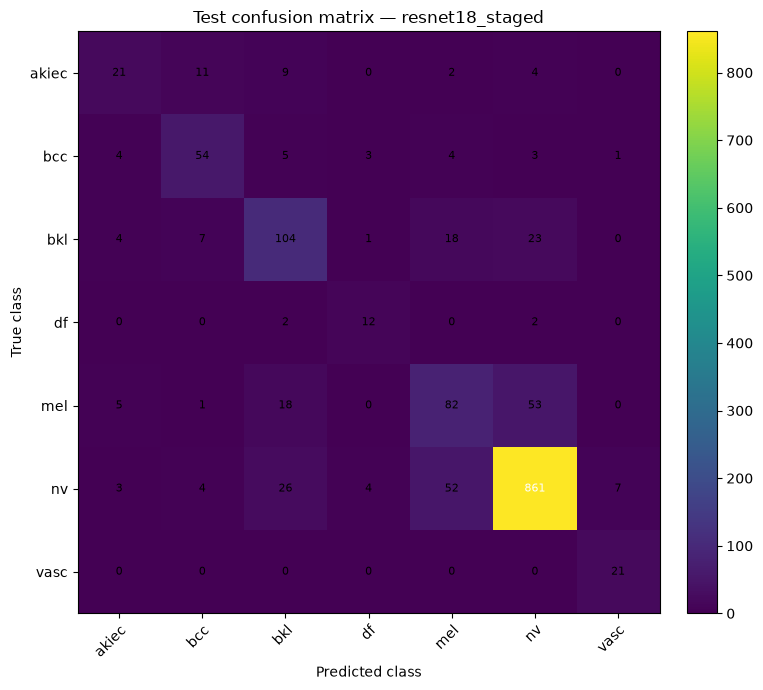

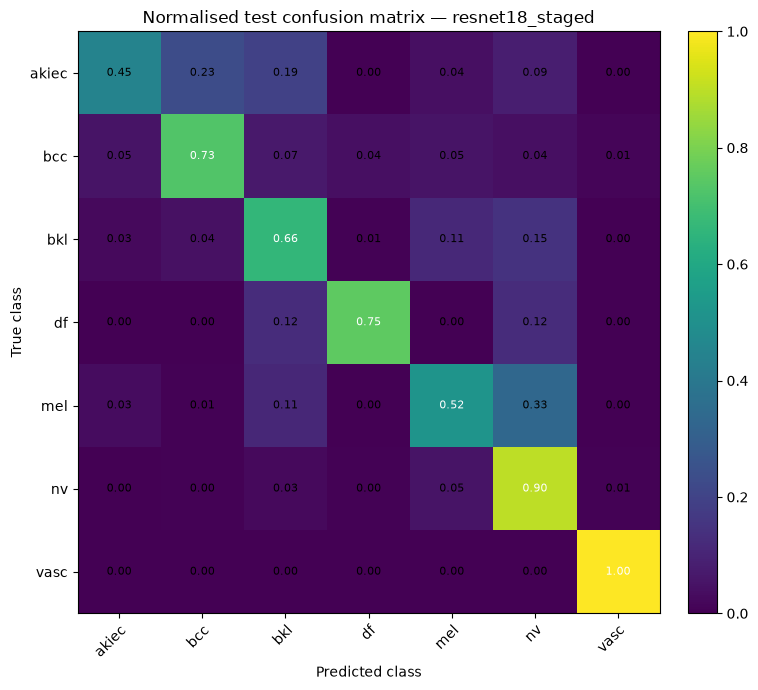

Held-out evaluation completed for: resnet18_staged, compact_cnn
Selected model for detailed reporting: resnet18_staged


,model,test_accuracy,test_balanced_accuracy,test_macro_f1,test_weighted_f1
1,resnet18_staged,0.807128,0.714910,0.684587,0.806919
0,compact_cnn,0.666667,0.398945,0.405262,0.682127


,model,target,precision,recall,f1_score,support
0,resnet18_staged,akiec,0.567568,0.446809,0.500000,47
1,resnet18_staged,mel,0.518987,0.515723,0.517350,159
2,resnet18_staged,bkl,0.634146,0.662420,0.647975,157
3,resnet18_staged,bcc,0.701299,0.729730,0.715232,74
4,resnet18_staged,df,0.600000,0.750000,0.666667,16
5,resnet18_staged,nv,0.910148,0.899687,0.904887,957
6,resnet18_staged,vasc,0.724138,1.000000,0.840000,21


In [8]:
# Imports required for held-out evaluation and visualisation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)

def collect_model_predictions(
    model: nn.Module,
    data_loader: DataLoader,
) -> pd.DataFrame:
    """
    Generate image-level probabilities and predictions.

    Input:
    ------
    model : nn.Module
        Trained image classifier.
    data_loader : DataLoader
        Data loader for the evaluation partition.

    Outputs:
    --------
    prediction_table : pd.DataFrame
        Image identifiers, targets, predictions and class probabilities.

    Author:
    -------
    Rodrigo Kang
    """
    model = model.to(device)
    model.eval()

    prediction_records = []

    with torch.inference_mode():
        for image_batch, target_batch, image_identifiers in data_loader:
            image_batch = image_batch.to(device, non_blocking=True)

            logits = model(image_batch)
            probabilities = torch.softmax(logits, dim=1)
            predictions = probabilities.argmax(dim=1)

            probabilities_array = probabilities.cpu().numpy()
            predictions_array = predictions.cpu().numpy()
            targets_array = target_batch.numpy()

            for row_index, image_identifier in enumerate(image_identifiers):
                record = {
                    "isic_id": image_identifier,
                    "target_index": int(targets_array[row_index]),
                    "prediction_index": int(
                        predictions_array[row_index]
                    ),
                    "target": index_to_class[
                        int(targets_array[row_index])
                    ],
                    "prediction": index_to_class[
                        int(predictions_array[row_index])
                    ],
                    "correct_prediction": (
                        int(targets_array[row_index])
                        == int(predictions_array[row_index])
                    ),
                    "predicted_probability": float(
                        probabilities_array[
                            row_index,
                            predictions_array[row_index],
                        ]
                    ),
                }

                for class_index, class_name in index_to_class.items():
                    record[f"probability_{class_name}"] = float(
                        probabilities_array[row_index, class_index]
                    )

                prediction_records.append(record)

    model.to("cpu")

    return pd.DataFrame(prediction_records)

def summarise_model_performance(
    model_name: str,
    prediction_table: pd.DataFrame,
) -> tuple[dict[str, float], pd.DataFrame]:
    """
    Summarise overall and class-level classification performance.

    Input:
    ------
    model_name : str
        Stable model identifier.
    prediction_table : pd.DataFrame
        Held-out predictions and ground-truth labels.

    Outputs:
    --------
    overall_metrics : dict[str, float]
        Aggregate test metrics.
    class_metrics : pd.DataFrame
        Precision, recall, F1 and support by class.

    Author:
    -------
    Rodrigo Kang
    """
    targets = prediction_table["target_index"].to_numpy()
    predictions = prediction_table["prediction_index"].to_numpy()

    precision, recall, f1, support = precision_recall_fscore_support(
        targets,
        predictions,
        labels=list(range(number_of_classes)),
        zero_division=0,
    )

    overall_metrics = {
        "model": model_name,
        "test_accuracy": accuracy_score(targets, predictions),
        "test_balanced_accuracy": balanced_accuracy_score(
            targets,
            predictions,
        ),
        "test_macro_f1": f1_score(
            targets,
            predictions,
            average="macro",
            zero_division=0,
        ),
        "test_weighted_f1": f1_score(
            targets,
            predictions,
            average="weighted",
            zero_division=0,
        ),
    }

    class_metrics = pd.DataFrame(
        {
            "model": model_name,
            "target": class_names,
            "precision": precision,
            "recall": recall,
            "f1_score": f1,
            "support": support.astype("int64"),
        }
    )

    return overall_metrics, class_metrics

def plot_confusion_matrix(
    confusion_values: np.ndarray,
    labels: list[str],
    title: str,
    output_path: Path,
    normalised: bool = False,
) -> None:
    """
    Plot and save a confusion matrix.

    Input:
    ------
    confusion_values : np.ndarray
        Square confusion matrix.
    labels : list[str]
        Ordered class labels.
    title : str
        Figure title.
    output_path : Path
        Destination PNG path.
    normalised : bool
        Whether values represent row-normalised proportions.

    Outputs:
    --------
    None
        The figure is saved to disk and displayed.

    Author:
    -------
    Rodrigo Kang
    """
    figure, axis = plt.subplots(figsize=(8, 7))

    image = axis.imshow(confusion_values, interpolation="nearest")
    figure.colorbar(image, ax=axis, fraction=0.046, pad=0.04)

    axis.set(
        xticks=np.arange(len(labels)),
        yticks=np.arange(len(labels)),
        xticklabels=labels,
        yticklabels=labels,
        xlabel="Predicted class",
        ylabel="True class",
        title=title,
    )
    plt.setp(
        axis.get_xticklabels(),
        rotation=45,
        ha="right",
        rotation_mode="anchor",
    )

    threshold = (
        confusion_values.max() / 2
        if confusion_values.size
        else 0
    )

    for row_index in range(confusion_values.shape[0]):
        for column_index in range(confusion_values.shape[1]):
            value = confusion_values[row_index, column_index]
            annotation = (
                f"{value:.2f}" if normalised else f"{int(value)}"
            )
            axis.text(
                column_index,
                row_index,
                annotation,
                ha="center",
                va="center",
                color="white" if value > threshold else "black",
                fontsize=8,
            )

    figure.tight_layout()
    figure.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(figure)

test_prediction_tables = {}
overall_performance_records = []
class_performance_tables = []

for model_name, model in trained_models.items():
    predictions = collect_model_predictions(
        model=model,
        data_loader=test_loader,
    )
    predictions["model"] = model_name

    overall_metrics, class_metrics = summarise_model_performance(
        model_name=model_name,
        prediction_table=predictions,
    )

    test_prediction_tables[model_name] = predictions
    overall_performance_records.append(overall_metrics)
    class_performance_tables.append(class_metrics)

    predictions.to_csv(
        tables_dir / f"{model_name}-test-predictions.csv",
        index=False,
    )

overall_test_performance = pd.DataFrame(
    overall_performance_records
).sort_values(
    "test_macro_f1",
    ascending=False,
)

class_test_performance = pd.concat(
    class_performance_tables,
    ignore_index=True,
)

overall_test_performance.to_csv(
    tables_dir / "test-performance-summary.csv",
    index=False,
)
class_test_performance.to_csv(
    tables_dir / "test-class-performance.csv",
    index=False,
)

selected_test_predictions = test_prediction_tables[
    selected_model_name
]

selected_targets = selected_test_predictions[
    "target_index"
].to_numpy()
selected_predictions = selected_test_predictions[
    "prediction_index"
].to_numpy()

confusion_counts = confusion_matrix(
    selected_targets,
    selected_predictions,
    labels=list(range(number_of_classes)),
)

row_totals = confusion_counts.sum(axis=1, keepdims=True)
confusion_normalised = np.divide(
    confusion_counts,
    row_totals,
    out=np.zeros_like(confusion_counts, dtype=float),
    where=row_totals != 0,
)

plot_confusion_matrix(
    confusion_values=confusion_counts,
    labels=class_names,
    title=(
        f"Test confusion matrix — {selected_model_name}"
    ),
    output_path=(
        figures_dir
        / f"{selected_model_name}-test-confusion-matrix-counts.png"
    ),
    normalised=False,
)

plot_confusion_matrix(
    confusion_values=confusion_normalised,
    labels=class_names,
    title=(
        f"Normalised test confusion matrix — "
        f"{selected_model_name}"
    ),
    output_path=(
        figures_dir
        / f"{selected_model_name}-test-confusion-matrix-normalised.png"
    ),
    normalised=True,
)

selected_class_performance = (
    class_test_performance[
        class_test_performance["model"] == selected_model_name
    ]
    .sort_values("recall")
    .reset_index(drop=True)
)

evaluation_metadata = {
    "selected_model": selected_model_name,
    "selection_metric": "validation_macro_f1",
    "test_metrics": (
        overall_test_performance[
            overall_test_performance["model"] == selected_model_name
        ]
        .iloc[0]
        .to_dict()
    ),
    "lowest_recall_class": (
        selected_class_performance.iloc[0]["target"]
    ),
    "lowest_recall_value": float(
        selected_class_performance.iloc[0]["recall"]
    ),
}

with (metadata_output_dir / "test-evaluation.json").open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(evaluation_metadata, file, indent=2)

print(
    "Held-out evaluation completed for: "
    f"{', '.join(overall_test_performance['model'])}"
)
print(
    "Selected model for detailed reporting: "
    f"{selected_model_name}"
)

display(overall_test_performance)
display(selected_class_performance)

## Triage-Oriented Evaluation and Uncertainty

Multiclass macro F1 remains important, but a triage system also needs explicit sensitivity-oriented metrics. This section therefore evaluates:

- melanoma sensitivity;
- sensitivity for a broader priority-review grouping (`akiec`, `bcc`, and `mel`);
- specificity, positive predictive value and negative predictive value for that grouping;
- lesion-level bootstrap confidence intervals.

Bootstrap resampling is performed by lesion rather than by image so that repeated photographs of the same lesion remain together. The intervals quantify sampling uncertainty for the fixed held-out test partition; they do not substitute for external clinical validation.

In [9]:
# Triage-oriented metrics and lesion-level bootstrap intervals
from sklearn.metrics import (
    precision_score,
    recall_score,
)

priority_review_classes = {"akiec", "bcc", "mel"}
bootstrap_iterations = 1000
bootstrap_random_seed = random_seed + 100


def calculate_binary_triage_metrics(
    prediction_table: pd.DataFrame,
) -> dict[str, float]:
    """Calculate metrics for the priority-review versus other grouping."""
    priority_indices = {
        class_to_index[class_name]
        for class_name in priority_review_classes
    }
    targets = prediction_table["target_index"].isin(
        priority_indices
    ).astype(int)
    predictions = prediction_table["prediction_index"].isin(
        priority_indices
    ).astype(int)

    true_positive = int(((targets == 1) & (predictions == 1)).sum())
    true_negative = int(((targets == 0) & (predictions == 0)).sum())
    false_positive = int(((targets == 0) & (predictions == 1)).sum())
    false_negative = int(((targets == 1) & (predictions == 0)).sum())

    sensitivity = (
        true_positive / (true_positive + false_negative)
        if true_positive + false_negative
        else np.nan
    )
    specificity = (
        true_negative / (true_negative + false_positive)
        if true_negative + false_positive
        else np.nan
    )
    positive_predictive_value = (
        true_positive / (true_positive + false_positive)
        if true_positive + false_positive
        else np.nan
    )
    negative_predictive_value = (
        true_negative / (true_negative + false_negative)
        if true_negative + false_negative
        else np.nan
    )

    return {
        "triage_sensitivity": sensitivity,
        "triage_specificity": specificity,
        "triage_positive_predictive_value": (
            positive_predictive_value
        ),
        "triage_negative_predictive_value": (
            negative_predictive_value
        ),
        "triage_true_positive": true_positive,
        "triage_true_negative": true_negative,
        "triage_false_positive": false_positive,
        "triage_false_negative": false_negative,
    }

def calculate_extended_metrics(
    prediction_table: pd.DataFrame,
) -> dict[str, float]:
    """Calculate multiclass and triage-oriented evaluation metrics."""
    targets = prediction_table["target_index"].to_numpy()
    predictions = prediction_table["prediction_index"].to_numpy()

    melanoma_targets = targets == melanoma_class_index
    melanoma_predictions = predictions == melanoma_class_index

    metrics = {
        "macro_f1": f1_score(
            targets,
            predictions,
            average="macro",
            zero_division=0,
        ),
        "balanced_accuracy": balanced_accuracy_score(
            targets,
            predictions,
        ),
        "melanoma_recall": recall_score(
            melanoma_targets,
            melanoma_predictions,
            zero_division=0,
        ),
        "melanoma_precision": precision_score(
            melanoma_targets,
            melanoma_predictions,
            zero_division=0,
        ),
    }
    metrics.update(calculate_binary_triage_metrics(prediction_table))
    return metrics

def lesion_level_bootstrap_intervals(
    prediction_table: pd.DataFrame,
    metadata_table: pd.DataFrame,
    iterations: int = 1000,
    seed: int = 142,
) -> pd.DataFrame:
    """Estimate percentile intervals by resampling lesions with replacement."""
    table = prediction_table.merge(
        metadata_table[["isic_id", "lesion_id"]],
        on="isic_id",
        how="left",
        validate="one_to_one",
    )
    if table["lesion_id"].isna().any():
        raise ValueError("Missing lesion IDs after prediction merge.")

    lesion_groups = {
        lesion_id: group.copy()
        for lesion_id, group in table.groupby("lesion_id")
    }
    lesion_ids = np.array(list(lesion_groups))
    random_generator = np.random.default_rng(seed)
    bootstrap_records = []

    for iteration in range(iterations):
        sampled_lesions = random_generator.choice(
            lesion_ids,
            size=len(lesion_ids),
            replace=True,
        )
        sampled_table = pd.concat(
            [lesion_groups[lesion_id] for lesion_id in sampled_lesions],
            ignore_index=True,
        )
        bootstrap_records.append(
            {
                "iteration": iteration,
                **calculate_extended_metrics(sampled_table),
            }
        )

    bootstrap_table = pd.DataFrame(bootstrap_records)
    interval_records = []

    for metric_name in [
        column
        for column in bootstrap_table.columns
        if column != "iteration"
        and not column.endswith(
            (
                "true_positive",
                "true_negative",
                "false_positive",
                "false_negative",
            )
        )
    ]:
        metric_values = bootstrap_table[metric_name].dropna()
        interval_records.append(
            {
                "metric": metric_name,
                "estimate": calculate_extended_metrics(table)[metric_name],
                "lower_95_percent": metric_values.quantile(0.025),
                "upper_95_percent": metric_values.quantile(0.975),
            }
        )

    return pd.DataFrame(interval_records), bootstrap_table

selected_prediction_table = model_prediction_tables[
    selected_model_name
].copy()

triage_metrics = calculate_extended_metrics(
    selected_prediction_table
)
triage_metrics_table = pd.DataFrame(
    [{"model": selected_model_name, **triage_metrics}]
)

bootstrap_intervals, bootstrap_samples = (
    lesion_level_bootstrap_intervals(
        selected_prediction_table,
        test_metadata,
        iterations=bootstrap_iterations,
        seed=bootstrap_random_seed,
    )
)

triage_metrics_table.to_csv(
    tables_dir / "triage-oriented-metrics.csv",
    index=False,
)
bootstrap_intervals.to_csv(
    tables_dir / "lesion-bootstrap-confidence-intervals.csv",
    index=False,
)
bootstrap_samples.to_csv(
    tables_dir / "lesion-bootstrap-samples.csv",
    index=False,
)

display(triage_metrics_table)
display(bootstrap_intervals)

NameError: name 'model_prediction_tables' is not defined

## Error Analysis and Interpretation

This section examines where the selected model fails and whether those failures are concentrated in particular class pairs or confidence ranges. The aim is not to overstate model capability, but to identify the practical limits of the current pipeline and the types of mistakes that would require additional review in a triage setting.

The analysis focuses on three questions. First, which true–predicted class pairs dominate the error profile? Second, are incorrect predictions associated with lower confidence than correct predictions? Third, which individual cases are both incorrect and highly confident, since these represent the most concerning failure mode for a decision-support workflow.

Because this notebook operates at image level, the interpretation remains descriptive rather than clinical. The results should be read as evidence about model behaviour on the held-out partition, not as proof of diagnostic safety or generalisability.

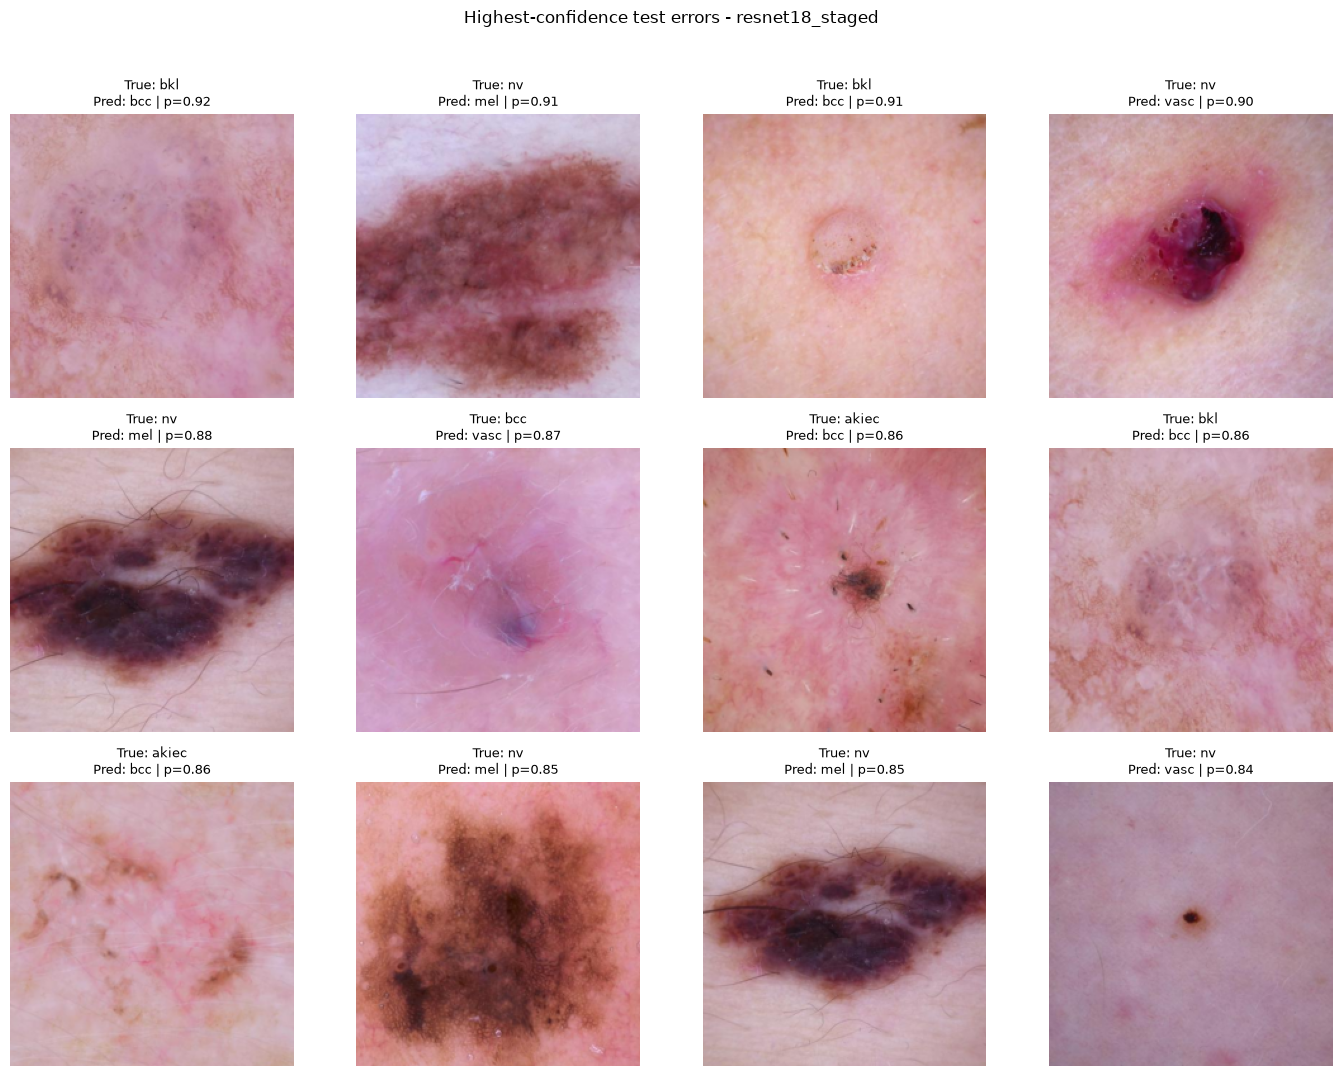

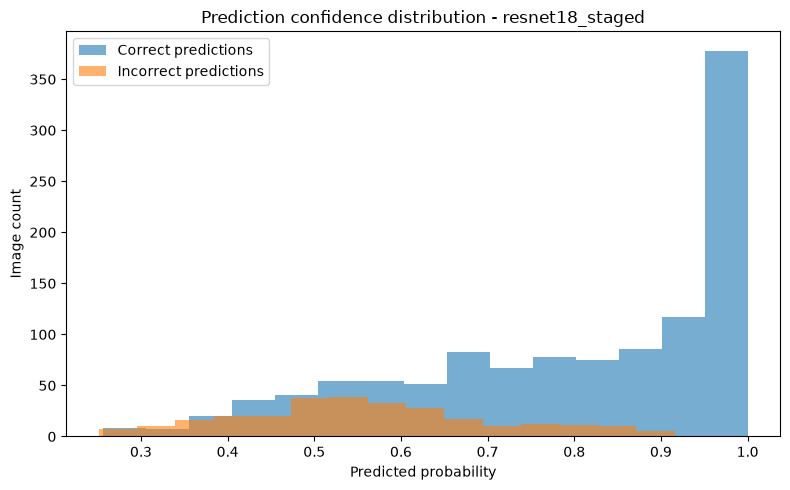

Error analysis completed for resnet18_staged.
High-confidence errors (p >= 0.80): 20


,target,prediction,error_count,error_share
0,mel,nv,53,0.192029
1,nv,mel,52,0.188406
2,nv,bkl,26,0.094203
3,bkl,nv,23,0.083333
4,mel,bkl,18,0.065217
5,bkl,mel,18,0.065217
6,akiec,bcc,11,0.039855
7,akiec,bkl,9,0.032609
8,bkl,bcc,7,0.025362
9,nv,vasc,7,0.025362


,prediction_status,count,mean_confidence,median_confidence,minimum_confidence,maximum_confidence
0,incorrect,276,0.559413,0.547532,0.251166,0.916055
1,correct,1155,0.798543,0.853613,0.256614,0.999933


,isic_id,target_index,prediction_index,target,prediction,correct_prediction,predicted_probability,probability_akiec,probability_bcc,probability_bkl,probability_df,probability_mel,probability_nv,probability_vasc,model
0,ISIC_0025985,2,1,bkl,bcc,False,0.916055,0.008926,0.916055,0.070703,0.001112,0.001091,0.001393,0.000720,resnet18_staged
1,ISIC_0033425,5,4,nv,mel,False,0.914005,0.000656,0.000015,0.004510,0.000042,0.914005,0.080762,0.000011,resnet18_staged
2,ISIC_0029068,2,1,bkl,bcc,False,0.905622,0.013018,0.905622,0.040311,0.019278,0.004985,0.015063,0.001723,resnet18_staged
3,ISIC_0032860,5,6,nv,vasc,False,0.897285,0.000018,0.015287,0.000742,0.000119,0.084182,0.002367,0.897285,resnet18_staged
4,ISIC_0033472,5,4,nv,mel,False,0.880873,0.000086,0.000091,0.007241,0.000044,0.880873,0.110466,0.001200,resnet18_staged
5,ISIC_0032482,1,6,bcc,vasc,False,0.870597,0.000048,0.112943,0.000319,0.001000,0.000191,0.014902,0.870597,resnet18_staged
6,ISIC_0029598,0,1,akiec,bcc,False,0.864561,0.111510,0.864561,0.014780,0.000872,0.006823,0.001148,0.000306,resnet18_staged
7,ISIC_0026849,2,1,bkl,bcc,False,0.863565,0.025598,0.863565,0.076015,0.004000,0.022464,0.005070,0.003289,resnet18_staged
8,ISIC_0028132,0,1,akiec,bcc,False,0.860062,0.128578,0.860062,0.001128,0.004636,0.001627,0.002749,0.001220,resnet18_staged
9,ISIC_0028999,5,4,nv,mel,False,0.854940,0.000176,0.000071,0.013997,0.000006,0.854940,0.130788,0.000021,resnet18_staged


In [10]:
# Imports required for error analysis
from itertools import islice

def build_error_pair_summary(
    prediction_table: pd.DataFrame,
) -> pd.DataFrame:
    """
    Summarise the most frequent true-predicted class error pairs.

    Input:
    ------
    prediction_table : pd.DataFrame
        Image-level test predictions for the selected model.

    Outputs:
    --------
    error_pair_summary : pd.DataFrame
        Error counts and proportions by true and predicted class.

    Author:
    -------
    Rodrigo Kang
    """
    errors = prediction_table.loc[
        ~prediction_table["correct_prediction"]
    ].copy()

    if errors.empty:
        return pd.DataFrame(
            columns=[
                "target",
                "prediction",
                "error_count",
                "error_share",
            ]
        )

    error_pair_summary = (
        errors.groupby(["target", "prediction"])
        .size()
        .rename("error_count")
        .reset_index()
        .sort_values("error_count", ascending=False)
        .reset_index(drop=True)
    )

    error_pair_summary["error_share"] = (
        error_pair_summary["error_count"]
        / error_pair_summary["error_count"].sum()
    )

    return error_pair_summary

def summarise_prediction_confidence(
    prediction_table: pd.DataFrame,
) -> pd.DataFrame:
    """
    Compare confidence distributions for correct and incorrect predictions.

    Input:
    ------
    prediction_table : pd.DataFrame
        Image-level test predictions.

    Outputs:
    --------
    confidence_summary : pd.DataFrame
        Count and confidence summaries by prediction status.

    Author:
    -------
    Rodrigo Kang
    """
    confidence_summary = (
        prediction_table.groupby("correct_prediction")[
            "predicted_probability"
        ]
        .agg(
            count="size",
            mean_confidence="mean",
            median_confidence="median",
            minimum_confidence="min",
            maximum_confidence="max",
        )
        .reset_index()
    )

    confidence_summary["prediction_status"] = confidence_summary[
        "correct_prediction"
    ].map(
        {
            True: "correct",
            False: "incorrect",
        }
    )

    return confidence_summary[
        [
            "prediction_status",
            "count",
            "mean_confidence",
            "median_confidence",
            "minimum_confidence",
            "maximum_confidence",
        ]
    ]

def plot_confidence_distributions(
    prediction_table: pd.DataFrame,
    output_path: Path,
) -> None:
    """
    Plot confidence distributions for correct and incorrect predictions.

    Input:
    ------
    prediction_table : pd.DataFrame
        Image-level test predictions.
    output_path : Path
        Destination PNG path.

    Outputs:
    --------
    None
        The figure is saved and displayed.

    Author:
    -------
    Rodrigo Kang
    """
    correct_confidence = prediction_table.loc[
        prediction_table["correct_prediction"],
        "predicted_probability",
    ]
    incorrect_confidence = prediction_table.loc[
        ~prediction_table["correct_prediction"],
        "predicted_probability",
    ]

    figure, axis = plt.subplots(figsize=(8, 5))

    axis.hist(
        correct_confidence,
        bins=15,
        alpha=0.60,
        label="Correct predictions",
    )
    axis.hist(
        incorrect_confidence,
        bins=15,
        alpha=0.60,
        label="Incorrect predictions",
    )

    axis.set(
        xlabel="Predicted probability",
        ylabel="Image count",
        title=(
            f"Prediction confidence distribution - "
            f"{selected_model_name}"
        ),
    )
    axis.legend()

    figure.tight_layout()
    figure.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(figure)

def display_high_confidence_errors(
    prediction_table: pd.DataFrame,
    dataset: ZipImageDataset,
    maximum_examples: int = 12,
) -> pd.DataFrame:
    """
    Display the most confident incorrect predictions.

    Input:
    ------
    prediction_table : pd.DataFrame
        Image-level test predictions.
    dataset : ZipImageDataset
        Evaluation dataset containing image access information.
    maximum_examples : int
        Maximum number of error cases to display.

    Outputs:
    --------
    selected_errors : pd.DataFrame
        Metadata for displayed high-confidence errors.

    Author:
    -------
    Rodrigo Kang
    """
    selected_errors = (
        prediction_table.loc[
            ~prediction_table["correct_prediction"]
        ]
        .sort_values(
            "predicted_probability",
            ascending=False,
        )
        .head(maximum_examples)
        .reset_index(drop=True)
    )

    if selected_errors.empty:
        print("No incorrect predictions were found.")
        return selected_errors

    columns = 4
    rows = int(np.ceil(len(selected_errors) / columns))

    figure, axes = plt.subplots(
        rows,
        columns,
        figsize=(14, 3.5 * rows),
    )
    axes = np.atleast_1d(axes).ravel()

    inverse_normalise = transforms.Normalize(
        mean=tuple(
            -mean_value / std_value
            for mean_value, std_value in zip(
                imagenet_mean,
                imagenet_std,
            )
        ),
        std=tuple(
            1 / std_value
            for std_value in imagenet_std
        ),
    )

    metadata_index = {
        image_identifier: index
        for index, image_identifier in enumerate(
            dataset.metadata_table["isic_id"]
        )
    }

    for axis, (_, error_record) in zip(
        axes,
        selected_errors.iterrows(),
    ):
        image_identifier = error_record["isic_id"]
        dataset_index = metadata_index[image_identifier]

        image_tensor, _, _ = dataset[dataset_index]
        display_tensor = inverse_normalise(
            image_tensor
        ).clamp(0, 1)
        display_image = display_tensor.permute(1, 2, 0).numpy()

        axis.imshow(display_image)
        axis.set_title(
            f"True: {error_record['target']}\n"
            f"Pred: {error_record['prediction']} | "
            f"p={error_record['predicted_probability']:.2f}",
            fontsize=9,
        )
        axis.axis("off")

    for axis in islice(axes, len(selected_errors), None):
        axis.axis("off")

    figure.suptitle(
        f"Highest-confidence test errors - {selected_model_name}",
        y=1.02,
    )
    figure.tight_layout()
    figure.savefig(
        figures_dir
        / f"{selected_model_name}-high-confidence-errors.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()
    plt.close(figure)

    return selected_errors

selected_error_pairs = build_error_pair_summary(
    selected_test_predictions
)

selected_confidence_summary = summarise_prediction_confidence(
    selected_test_predictions
)

high_confidence_errors = display_high_confidence_errors(
    prediction_table=selected_test_predictions,
    dataset=test_dataset,
    maximum_examples=12,
)

plot_confidence_distributions(
    prediction_table=selected_test_predictions,
    output_path=(
        figures_dir
        / f"{selected_model_name}-confidence-distributions.png"
    ),
)

selected_error_pairs.to_csv(
    tables_dir / "selected-model-error-pairs.csv",
    index=False,
)
selected_confidence_summary.to_csv(
    tables_dir / "selected-model-confidence-summary.csv",
    index=False,
)
high_confidence_errors.to_csv(
    tables_dir / "selected-model-high-confidence-errors.csv",
    index=False,
)

most_common_error_pair = (
    selected_error_pairs.iloc[0].to_dict()
    if not selected_error_pairs.empty
    else None
)

incorrect_predictions = selected_test_predictions.loc[
    ~selected_test_predictions["correct_prediction"]
]

error_analysis_metadata = {
    "selected_model": selected_model_name,
    "test_image_count": int(len(selected_test_predictions)),
    "test_error_count": int(len(incorrect_predictions)),
    "test_error_rate": float(
        len(incorrect_predictions)
        / len(selected_test_predictions)
    ),
    "most_common_error_pair": most_common_error_pair,
    "high_confidence_error_threshold": 0.80,
    "high_confidence_error_count": int(
        (
            incorrect_predictions["predicted_probability"]
            >= 0.80
        ).sum()
    ),
}

with (metadata_output_dir / "error-analysis.json").open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(error_analysis_metadata, file, indent=2)

print(
    f"Error analysis completed for {selected_model_name}."
)
print(
    "High-confidence errors (p >= 0.80): "
    f"{error_analysis_metadata['high_confidence_error_count']}"
)

display(selected_error_pairs.head(15))
display(selected_confidence_summary)
display(high_confidence_errors)

## Additional Experiments

This section examines two practical extensions that are directly relevant to a triage-oriented classifier: probability calibration and selective prediction.

A scalar temperature is fitted on validation logits and then applied unchanged to the held-out test logits. Calibration is assessed through negative log-likelihood, multiclass Brier score and expected calibration error. The section then evaluates confidence-based abstention, showing how performance changes when low-confidence cases are referred for review rather than classified automatically.

These analyses do not establish clinical safety. They provide a more realistic view of how model confidence might be used in a decision-support workflow while preserving the separation between validation-based tuning and final test evaluation.

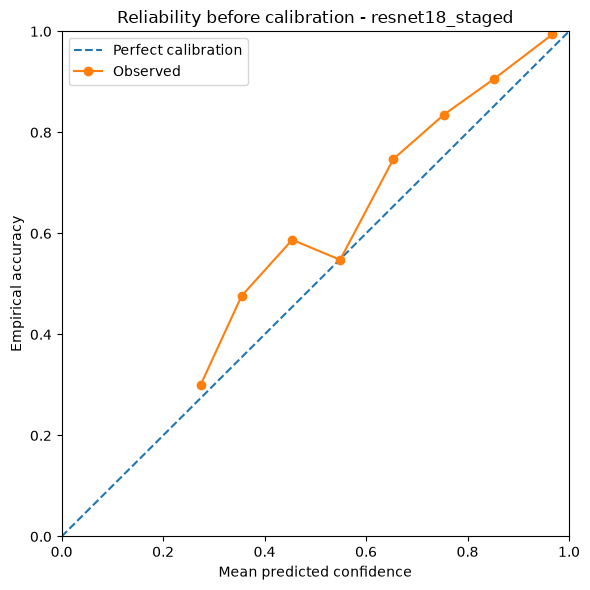

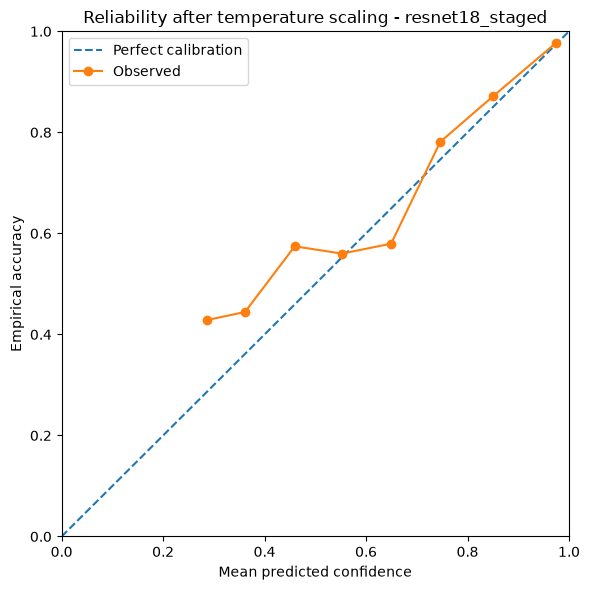

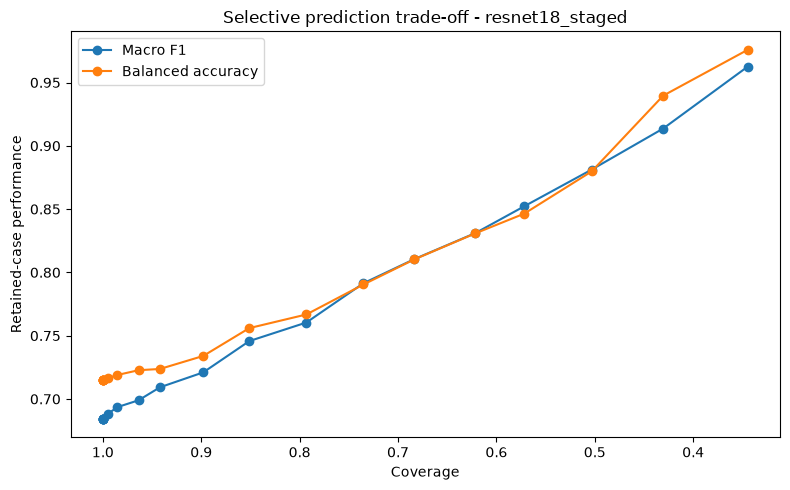

Temperature fitted on validation data: 0.8090


,probability_version,temperature,negative_log_likelihood,multiclass_brier_score,expected_calibration_error
0,uncalibrated,1.000000,0.533809,0.281094,0.055019
1,temperature_scaled,0.809043,0.520845,0.276992,0.027349


,confidence_threshold,retained_count,coverage,accuracy,balanced_accuracy,macro_f1
0,0.00,1431,1.000000,0.807128,0.714910,0.684587
1,0.05,1431,1.000000,0.807128,0.714910,0.684587
2,0.10,1431,1.000000,0.807128,0.714910,0.684587
3,0.15,1431,1.000000,0.807128,0.714910,0.684587
4,0.20,1431,1.000000,0.807128,0.714910,0.684587
5,0.25,1431,1.000000,0.807128,0.714910,0.684587
6,0.30,1424,0.995108,0.808989,0.716375,0.688140
7,0.35,1410,0.985325,0.812057,0.718958,0.693566
8,0.40,1379,0.963662,0.820885,0.722747,0.698998
9,0.45,1348,0.941999,0.827893,0.723715,0.709242


NameError: name 'selected_prediction_table' is not defined

In [11]:
# Imports required for calibration and selective prediction
from scipy.optimize import minimize_scalar
from sklearn.metrics import log_loss

def collect_logits(model, data_loader):
    """Collect logits, labels and image identifiers for one partition."""
    model = model.to(device)
    model.eval()
    records = []

    with torch.inference_mode():
        for images, targets, identifiers in data_loader:
            logits = model(images.to(device)).cpu().numpy()
            for row_index, identifier in enumerate(identifiers):
                record = {
                    "isic_id": identifier,
                    "target_index": int(targets[row_index]),
                }
                for class_index, class_name in index_to_class.items():
                    record[f"logit_{class_name}"] = float(
                        logits[row_index, class_index]
                    )
                records.append(record)

    model.to("cpu")
    return pd.DataFrame(records)

def softmax_numpy(logits):
    """
    Calculate numerically stable softmax probabilities.
    """
    shifted = logits - logits.max(axis=1, keepdims=True)
    exponentiated = np.exp(shifted)
    return exponentiated / exponentiated.sum(axis=1, keepdims=True)

def fit_temperature(validation_logits, validation_targets):
    """
    Fit a positive scalar temperature on validation NLL.
    """
    def objective(log_temperature):
        temperature = float(np.exp(log_temperature))
        probabilities = softmax_numpy(validation_logits / temperature)
        return log_loss(
            validation_targets,
            probabilities,
            labels=list(range(number_of_classes)),
        )

    result = minimize_scalar(
        objective,
        bounds=(-3.0, 3.0),
        method="bounded",
    )
    if not result.success:
        raise RuntimeError("Temperature optimisation did not converge.")
    return float(np.exp(result.x))


def multiclass_brier_score(targets, probabilities):
    """
    Calculate the multiclass Brier score.
    """
    one_hot_targets = np.eye(number_of_classes)[targets]
    return float(
        np.mean(np.sum((probabilities - one_hot_targets) ** 2, axis=1))
    )


def expected_calibration_error(targets, probabilities, bins=10):
    """
    Estimate expected calibration error from confidence bins.
    """
    predictions = probabilities.argmax(axis=1)
    confidence = probabilities.max(axis=1)
    correctness = predictions == targets
    edges = np.linspace(0.0, 1.0, bins + 1)
    error = 0.0

    for bin_index in range(bins):
        lower, upper = edges[bin_index], edges[bin_index + 1]
        in_bin = (
            (confidence >= lower)
            & (confidence <= upper if bin_index == bins - 1 else confidence < upper)
        )
        if np.any(in_bin):
            error += abs(
                correctness[in_bin].mean() - confidence[in_bin].mean()
            ) * in_bin.mean()

    return float(error)


def build_reliability_table(targets, probabilities, bins=10):
    """
    Create confidence-bin summaries for reliability diagrams.
    """
    predictions = probabilities.argmax(axis=1)
    confidence = probabilities.max(axis=1)
    correctness = predictions == targets
    edges = np.linspace(0.0, 1.0, bins + 1)
    records = []

    for bin_index in range(bins):
        lower, upper = edges[bin_index], edges[bin_index + 1]
        in_bin = (
            (confidence >= lower)
            & (confidence <= upper if bin_index == bins - 1 else confidence < upper)
        )
        records.append({
            "bin_lower": lower,
            "bin_upper": upper,
            "sample_count": int(in_bin.sum()),
            "mean_confidence": float(confidence[in_bin].mean()) if np.any(in_bin) else np.nan,
            "empirical_accuracy": float(correctness[in_bin].mean()) if np.any(in_bin) else np.nan,
        })

    return pd.DataFrame(records)


def build_selective_prediction_curve(targets, probabilities):
    """
    Calculate coverage and retained-case metrics by confidence threshold.
    """
    predictions = probabilities.argmax(axis=1)
    confidence = probabilities.max(axis=1)
    records = []

    for threshold in np.arange(0.00, 1.00, 0.05):
        retained = confidence >= threshold
        retained_count = int(retained.sum())
        record = {
            "confidence_threshold": float(threshold),
            "retained_count": retained_count,
            "coverage": float(retained.mean()),
        }
        if retained_count:
            retained_targets = targets[retained]
            retained_predictions = predictions[retained]
            record.update({
                "accuracy": accuracy_score(retained_targets, retained_predictions),
                "balanced_accuracy": balanced_accuracy_score(retained_targets, retained_predictions),
                "macro_f1": f1_score(
                    retained_targets,
                    retained_predictions,
                    average="macro",
                    zero_division=0,
                ),
            })
        else:
            record.update({
                "accuracy": np.nan,
                "balanced_accuracy": np.nan,
                "macro_f1": np.nan,
            })
        records.append(record)

    return pd.DataFrame(records)


def plot_reliability(table, title, output_path):
    """
    Plot empirical accuracy against mean confidence.
    """
    table = table.dropna(subset=["mean_confidence", "empirical_accuracy"])
    figure, axis = plt.subplots(figsize=(6, 6))
    axis.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
    axis.plot(
        table["mean_confidence"],
        table["empirical_accuracy"],
        marker="o",
        label="Observed",
    )
    axis.set(
        xlim=(0, 1),
        ylim=(0, 1),
        xlabel="Mean predicted confidence",
        ylabel="Empirical accuracy",
        title=title,
    )
    axis.legend()
    figure.tight_layout()
    figure.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(figure)


def plot_selective_prediction(table, output_path):
    """
    Plot retained-case performance against coverage.
    """
    table = table.dropna(subset=["macro_f1", "balanced_accuracy"])
    figure, axis = plt.subplots(figsize=(8, 5))
    axis.plot(table["coverage"], table["macro_f1"], marker="o", label="Macro F1")
    axis.plot(
        table["coverage"],
        table["balanced_accuracy"],
        marker="o",
        label="Balanced accuracy",
    )
    axis.set(
        xlabel="Coverage",
        ylabel="Retained-case performance",
        title=f"Selective prediction trade-off - {selected_model_name}",
    )
    axis.invert_xaxis()
    axis.legend()
    figure.tight_layout()
    figure.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(figure)


selected_model_for_calibration = trained_models[selected_model_name]
validation_logits_table = collect_logits(
    selected_model_for_calibration,
    validation_loader,
)
test_logits_table = collect_logits(
    selected_model_for_calibration,
    test_loader,
)

logit_columns = [f"logit_{class_name}" for class_name in class_names]
validation_logits = validation_logits_table[logit_columns].to_numpy()
validation_targets = validation_logits_table["target_index"].to_numpy()
test_logits = test_logits_table[logit_columns].to_numpy()
test_targets = test_logits_table["target_index"].to_numpy()

temperature = fit_temperature(validation_logits, validation_targets)
uncalibrated_probabilities = softmax_numpy(test_logits)
calibrated_probabilities = softmax_numpy(test_logits / temperature)

calibration_summary = pd.DataFrame([
    {
        "probability_version": "uncalibrated",
        "temperature": 1.0,
        "negative_log_likelihood": log_loss(
            test_targets,
            uncalibrated_probabilities,
            labels=list(range(number_of_classes)),
        ),
        "multiclass_brier_score": multiclass_brier_score(
            test_targets,
            uncalibrated_probabilities,
        ),
        "expected_calibration_error": expected_calibration_error(
            test_targets,
            uncalibrated_probabilities,
        ),
    },
    {
        "probability_version": "temperature_scaled",
        "temperature": temperature,
        "negative_log_likelihood": log_loss(
            test_targets,
            calibrated_probabilities,
            labels=list(range(number_of_classes)),
        ),
        "multiclass_brier_score": multiclass_brier_score(
            test_targets,
            calibrated_probabilities,
        ),
        "expected_calibration_error": expected_calibration_error(
            test_targets,
            calibrated_probabilities,
        ),
    },
])

uncalibrated_reliability = build_reliability_table(
    test_targets,
    uncalibrated_probabilities,
)
uncalibrated_reliability["probability_version"] = "uncalibrated"
calibrated_reliability = build_reliability_table(
    test_targets,
    calibrated_probabilities,
)
calibrated_reliability["probability_version"] = "temperature_scaled"
reliability_summary = pd.concat(
    [uncalibrated_reliability, calibrated_reliability],
    ignore_index=True,
)

selective_prediction_summary = build_selective_prediction_curve(
    test_targets,
    calibrated_probabilities,
)

calibration_summary.to_csv(
    tables_dir / "calibration-summary.csv",
    index=False,
)
reliability_summary.to_csv(
    tables_dir / "reliability-summary.csv",
    index=False,
)
selective_prediction_summary.to_csv(
    tables_dir / "selective-prediction-summary.csv",
    index=False,
)

plot_reliability(
    uncalibrated_reliability,
    f"Reliability before calibration - {selected_model_name}",
    figures_dir / f"{selected_model_name}-reliability-uncalibrated.png",
)
plot_reliability(
    calibrated_reliability,
    f"Reliability after temperature scaling - {selected_model_name}",
    figures_dir / f"{selected_model_name}-reliability-calibrated.png",
)
plot_selective_prediction(
    selective_prediction_summary,
    figures_dir / f"{selected_model_name}-selective-prediction.png",
)

with (metadata_output_dir / "additional-experiments.json").open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        {
            "selected_model": selected_model_name,
            "temperature": temperature,
            "calibration_fitted_on": "validation",
            "calibration_evaluated_on": "test",
            "selective_prediction_probabilities": "temperature_scaled",
        },
        file,
        indent=2,
    )

print(f"Temperature fitted on validation data: {temperature:.4f}")
display(calibration_summary)
display(selective_prediction_summary)

def build_class_conditional_selective_summary(
    prediction_table,
    calibrated_probabilities,
    thresholds=(0.50, 0.70, 0.85, 0.95),
):
    """
    Summarise retained coverage and recall by true class at each threshold.
    """
    augmented = prediction_table.copy()
    augmented["calibrated_prediction_index"] = (
        calibrated_probabilities.argmax(axis=1)
    )
    augmented["calibrated_confidence"] = (
        calibrated_probabilities.max(axis=1)
    )
    records = []

    for threshold in thresholds:
        retained = augmented[
            augmented["calibrated_confidence"] >= threshold
        ]
        for class_name in class_names:
            class_index = class_to_index[class_name]
            true_class = augmented[
                augmented["target_index"] == class_index
            ]
            retained_true_class = retained[
                retained["target_index"] == class_index
            ]
            correctly_retained = (
                retained_true_class["calibrated_prediction_index"]
                == class_index
            ).sum()

            records.append(
                {
                    "confidence_threshold": threshold,
                    "target": class_name,
                    "class_support": len(true_class),
                    "retained_count": len(retained_true_class),
                    "class_coverage": (
                        len(retained_true_class) / len(true_class)
                        if len(true_class)
                        else np.nan
                    ),
                    "retained_class_recall": (
                        correctly_retained / len(true_class)
                        if len(true_class)
                        else np.nan
                    ),
                }
            )

    return pd.DataFrame(records)


class_conditional_selective_summary = (
    build_class_conditional_selective_summary(
        selected_prediction_table,
        calibrated_test_probabilities,
    )
)
class_conditional_selective_summary.to_csv(
    tables_dir / "selective-prediction-by-class.csv",
    index=False,
)

melanoma_selective_summary = (
    class_conditional_selective_summary[
        class_conditional_selective_summary["target"] == "mel"
    ]
    .reset_index(drop=True)
)

print("Selective prediction by class:")
display(class_conditional_selective_summary)
print("Melanoma-specific selective prediction:")
display(melanoma_selective_summary)

## Optional Repeated-Split Robustness Experiment

A single lesion-level train/validation/test partition can produce unstable estimates for rare classes. The following optional block provides the structure for repeating the staged ResNet experiment under several random seeds.

It is disabled by default because it is computationally expensive. When enabled, each seed recreates lesion-disjoint partitions, trains only the staged ResNet-18 and records validation results. The held-out test set from the main experiment remains the only partition used for final reporting.

In [12]:
RUN_REPEATED_SPLIT_AUDIT = False
repeated_split_seeds = [17, 42, 73]

if RUN_REPEATED_SPLIT_AUDIT:
    repeated_split_records = []

    for audit_seed in repeated_split_seeds:
        (
            audit_train_metadata,
            audit_validation_metadata,
            _,
        ) = create_group_stratified_splits(
            metadata,
            audit_seed,
        )

        audit_train_dataset = ZipImageDataset(
            audit_train_metadata,
            image_archive_path,
            archive_lookup,
            transform=train_transform,
        )
        audit_validation_dataset = ZipImageDataset(
            audit_validation_metadata,
            image_archive_path,
            archive_lookup,
            transform=evaluation_transform,
        )

        audit_generator = torch.Generator()
        audit_generator.manual_seed(audit_seed)

        audit_train_loader = DataLoader(
            audit_train_dataset,
            batch_size=batch_size,
            shuffle=True,
            num_workers=number_of_workers,
            pin_memory=pin_memory,
            generator=audit_generator,
        )
        audit_validation_loader = DataLoader(
            audit_validation_dataset,
            batch_size=batch_size,
            shuffle=False,
            num_workers=number_of_workers,
            pin_memory=pin_memory,
        )

        audit_model = build_resnet18_classifier(
            number_of_classes=number_of_classes,
            use_pretrained_weights=True,
            dropout_probability=0.30,
        )

        audit_model, audit_history, audit_summary = (
            train_and_validate_model(
                model_name=f"resnet18_seed_{audit_seed}",
                model=audit_model,
                train_data_loader=audit_train_loader,
                validation_data_loader=audit_validation_loader,
                configuration=training_configuration[
                    "resnet18_staged"
                ],
            )
        )

        repeated_split_records.append(
            {
                "seed": audit_seed,
                **audit_summary,
            }
        )

        audit_train_dataset.close()
        audit_validation_dataset.close()

    repeated_split_summary = pd.DataFrame(
        repeated_split_records
    )
    repeated_split_summary.to_csv(
        tables_dir / "repeated-split-summary.csv",
        index=False,
    )
    display(repeated_split_summary)
else:
    print(
        "Repeated-split audit is disabled. Set "
        "RUN_REPEATED_SPLIT_AUDIT = True to run it."
    )

Repeated-split audit is disabled. Set RUN_REPEATED_SPLIT_AUDIT = True to run it.


## Final Remarks

This revised notebook tests whether the initial moderate result was caused by an overly conservative transfer-learning protocol. It retains the leakage-aware lesion-level split, but adds staged domain adaptation, class-weighted focal loss, longer optimisation, a triage-aware validation objective, lesion-level uncertainty intervals and class-conditional selective-prediction analysis.

A technically successful run is not automatically an adequate clinical result. The implementation should be considered satisfactory only when the held-out metrics show a defensible balance between multiclass performance, melanoma sensitivity, broader priority-review sensitivity and coverage. Confidence intervals and per-class support must be considered when deciding whether an apparent improvement is meaningful.

The resulting system remains a technical study and is not clinically validated.

The notebook implements a complete and leakage-aware workflow for multiclass skin-lesion image classification. It begins with lesion-level data partitioning, compares a compact convolutional baseline with a transfer-learning model, selects the preferred architecture using validation macro F1, and evaluates the selected model on a held-out test set. The analysis then moves beyond aggregate metrics by examining class-level recall, confusion patterns, high-confidence mistakes, probability calibration and selective prediction.

The central modelling result should be interpreted comparatively rather than diagnostically. The selected model is the one that provides the strongest validation macro F1 under the current experimental design; this does not establish clinical readiness. Performance on rare classes, sensitivity to acquisition conditions and the presence of confident errors remain more important than a single overall score.

Several design choices make the experiment more reliable. Images linked to the same lesion are kept within the same partition, class imbalance is addressed explicitly, model selection is separated from test evaluation, and probability calibration is fitted on validation data only. Reproducible tables, figures, metadata and checkpoints are exported throughout the workflow.

The main limitations are equally important. The data may not represent the full range of patients, devices, institutions and lesion presentations encountered in practice. Image labels may contain uncertainty, and class imbalance can leave minority-class estimates unstable. The notebook evaluates images rather than complete clinical cases and does not incorporate patient history, lesion evolution or clinician assessment. Consequently, the outputs should be treated as a technical demonstration of medical-image modelling and not as medical advice or an autonomous diagnostic system.

A practical continuation would focus on external validation, subgroup analysis, stronger uncertainty estimates and prospective evaluation of a human-in-the-loop triage policy. Further model complexity would only be justified if it produced consistent improvements in minority-class recall, calibration and robustness across genuinely independent data.

In [13]:
# Consolidated project summary and reproducibility manifest
selected_training_row = training_summary.loc[
    training_summary["model"] == selected_model_name
].iloc[0]

final_summary = {
    "project": "Medical Image Analysis for Skin Lesion Triage",
    "selected_model": selected_model_name,
    "selection_metric": (
        "0.70 * validation macro F1 + "
        "0.30 * validation melanoma recall"
    ),
    "selected_validation_selection_score": float(
        selected_training_row["best_validation_selection_score"]
    ),
    "selected_validation_macro_f1": float(
        selected_training_row["best_validation_macro_f1"]
    ),
    "selected_validation_melanoma_recall": float(
        selected_training_row[
            "best_validation_melanoma_recall"
        ]
    ),
    "test_metrics": (
        overall_test_performance.loc[
            overall_test_performance["model"] == selected_model_name
        ]
        .iloc[0]
        .to_dict()
    ),
    "triage_metrics": triage_metrics,
    "temperature_scaling_parameter": float(temperature),
    "data_partitioning": "lesion-level stratified group split",
    "fine_tuning_protocol": [
        "classification head",
        "layer4 plus classification head",
        "layer3 and layer4 plus classification head",
    ],
    "uncertainty_method": (
        "lesion-level percentile bootstrap on held-out test data"
    ),
    "clinical_status": (
        "technical demonstration; not clinically validated"
    ),
}

with (metadata_output_dir / "final-project-summary.json").open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(final_summary, file, indent=2)


artifact_manifest = pd.DataFrame(
    [
        {
            "artifact_type": "table",
            "artifact": "model-architecture-summary.csv",
            "purpose": "Model size and initial trainable parameters",
        },
        {
            "artifact_type": "table",
            "artifact": "training-history.csv",
            "purpose": "Stage- and epoch-level optimisation history",
        },
        {
            "artifact_type": "table",
            "artifact": "training-summary.csv",
            "purpose": "Triage-aware validation comparison",
        },
        {
            "artifact_type": "table",
            "artifact": "test-performance-summary.csv",
            "purpose": "Held-out aggregate multiclass performance",
        },
        {
            "artifact_type": "table",
            "artifact": "test-class-performance.csv",
            "purpose": "Held-out class-level performance",
        },
        {
            "artifact_type": "table",
            "artifact": "triage-oriented-metrics.csv",
            "purpose": "Melanoma and priority-review metrics",
        },
        {
            "artifact_type": "table",
            "artifact": "lesion-bootstrap-confidence-intervals.csv",
            "purpose": "Lesion-level uncertainty intervals",
        },
        {
            "artifact_type": "table",
            "artifact": "selected-model-error-pairs.csv",
            "purpose": "Dominant confusion patterns",
        },
        {
            "artifact_type": "table",
            "artifact": "calibration-summary.csv",
            "purpose": "Calibration before and after scaling",
        },
        {
            "artifact_type": "table",
            "artifact": "selective-prediction-summary.csv",
            "purpose": "Overall coverage-performance trade-off",
        },
        {
            "artifact_type": "table",
            "artifact": "selective-prediction-by-class.csv",
            "purpose": "Class-conditional coverage and retained recall",
        },
        {
            "artifact_type": "metadata",
            "artifact": "final-project-summary.json",
            "purpose": "Consolidated experiment summary",
        },
    ]
)

artifact_manifest.to_csv(
    tables_dir / "artifact-manifest.csv",
    index=False,
)

print("Project workflow completed.")
print(f"Selected model: {selected_model_name}")
print(
    "Held-out macro F1: "
    f"{final_summary['test_metrics']['test_macro_f1']:.4f}"
)
print(
    "Held-out melanoma recall: "
    f"{triage_metrics['melanoma_recall']:.4f}"
)
print(
    "Priority-review sensitivity: "
    f"{triage_metrics['triage_sensitivity']:.4f}"
)
print(
    "Clinical status: "
    f"{final_summary['clinical_status']}"
)

display(pd.DataFrame([final_summary]))
display(artifact_manifest)

NameError: name 'triage_metrics' is not defined